In [317]:
#from mca_shared_izzy.mca_shared_si_conc import dot_xa_masked
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [318]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import xeofs as xe
from pygments.modeline import modeline_re
import sys
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import warnings
import os
import requests
from bs4 import BeautifulSoup
#import copernicusmarine as cm
warnings.filterwarnings('ignore')

In [319]:
# constant
rho_a = 1.25 # air density kg m-3
cd_aw = 1.25e-3 # drag coeff
rho_w = 1028
cd_iw = 5.5e-3

In [320]:
import netCDF4
import h5netcdf

In [321]:
# #downloading SI_drift data noaa
# archive_url = "https://noaadata.apps.nsidc.org/NOAA/G02202_V5/south/monthly/"
#
# r = requests.get(archive_url)
#
# data = BeautifulSoup(r.text, "html.parser")
#
# for l in data.find_all("a")[1:]:
# 	r = requests.get(archive_url + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r.content)

In [322]:
# #downloading SI_conc data noaa
# archive_url_conc = "https://noaadata.apps.nsidc.org/NOAA/G02202_V4/south/monthly/"
#
# r_conc = requests.get(archive_url_conc)
#
# data_conc = BeautifulSoup(r_conc.text, "html.parser")
#
# for l in data_conc.find_all("a")[1:]:
# 	r_conc = requests.get(archive_url_conc + l["href"])
# 	with open(l["href"], "wb") as f:
#     	         f.write(r_conc.content)

In [323]:
path = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
save_dir = path + 'Oana/test_figs/'
aux_scripts = path + 'Scripts/aux_scripts/'
print(path)

workdir = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = workdir + 'Data/'
mca_dir = data_dir + 'mca_processing/'
clim_dir = data_dir + 'climate_indices/'
script_dir = workdir + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'
fig_dir = workdir + 'Figures/'
scores_comps_dir = mca_dir + 'scores_comps/'


sys.path.append(aux_scripts)
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
from regression_izzyv1 import linregress_3D_spatial_time
import aux_func as ft
import mca_preprocessing_func as mca_func

# dot_ds = xr.open_dataset(path + 'Data/Oana/original_fully_processed_oana_ds/dot_all_30bmedian_goco05c_sig3_1.nc')
#
dot_ds = xr.open_dataset('/Users/iw2g24/PycharmProjects/SLA_analysis/Data/dot_all_30bmedian_egm2008_sig3.nc')
bad_month_mask = dot_ds['bad_month_flag'].values
dot_ds = dot_ds.isel(time=~bad_month_mask)
dot_ds = dot_ds.sel(time=slice('2002-07-01', '2018-10-01'))

# print(dot_ds)
# ERA5 remap dataset
# ds_era5 = xr.open_dataset(path + 'Data/ERA5_u10v10_Antartica_2000-2023_' + gridtype + '.nc')
era5_ds = xr.open_dataset(path + 'Data/ERA5/era5_regridded_2002_2024_monthly.nc')

# sic_ds = xr.open_dataset(path + 'Data/NOAA_SIC_monthly/sic_regridded_2002_2024_monthly.nc')
# sid_ds  = xr.open_dataset(path + 'Data/NASA_SID_weekly/sid_regridded_2002_2024_monthly.nc')

sic_ds = xr.open_dataset(path + 'Data/NOAA_SIC_monthly/noaa_sic_2025_corrected.nc')
sid_ds  = xr.open_dataset(path + 'Data/NASA_SID_weekly/nasa_sid_2025_corrected.nc')


/Users/iw2g24/PycharmProjects/SLA_analysis/


In [324]:
dot = dot_ds.dot.values
lon = dot_ds.longitude.values
lat = dot_ds.latitude.values
dot_time = dot_ds.time.values
print(dot_ds.dot.shape)
# seamask
seamask = dot[:,:,0] / dot[:,:,0]
seamask[seamask == 0] = np.nan

era5_ds = era5_ds.sel(time=dot_time)
sic_ds = sic_ds.sel(time=dot_time)
sid_ds = sid_ds.sel(time=dot_time)


(360, 64, 193)


In [325]:
# For plotting (matches (lon, lat) data arrays)
llon_ij, llat_ij = np.meshgrid(lon, lat, indexing='ij')  # shape (lon, lat)

# For grad_sphere (expects lat, lon)
llon, llat = np.meshgrid(lon, lat)  # shape (lat, lon)
print("llon edges:", llon[0, 0], llon[0, -1])  # -179.5, 179.5
print("llat edges:", llat[0, 0], llat[-1, 0])  # lat min/max

llon edges: -179.5 179.5
llat edges: -81.75 -50.25


In [326]:
print(dot.shape)
print(era5_ds.u10.shape)

(360, 64, 193)
(360, 64, 193)


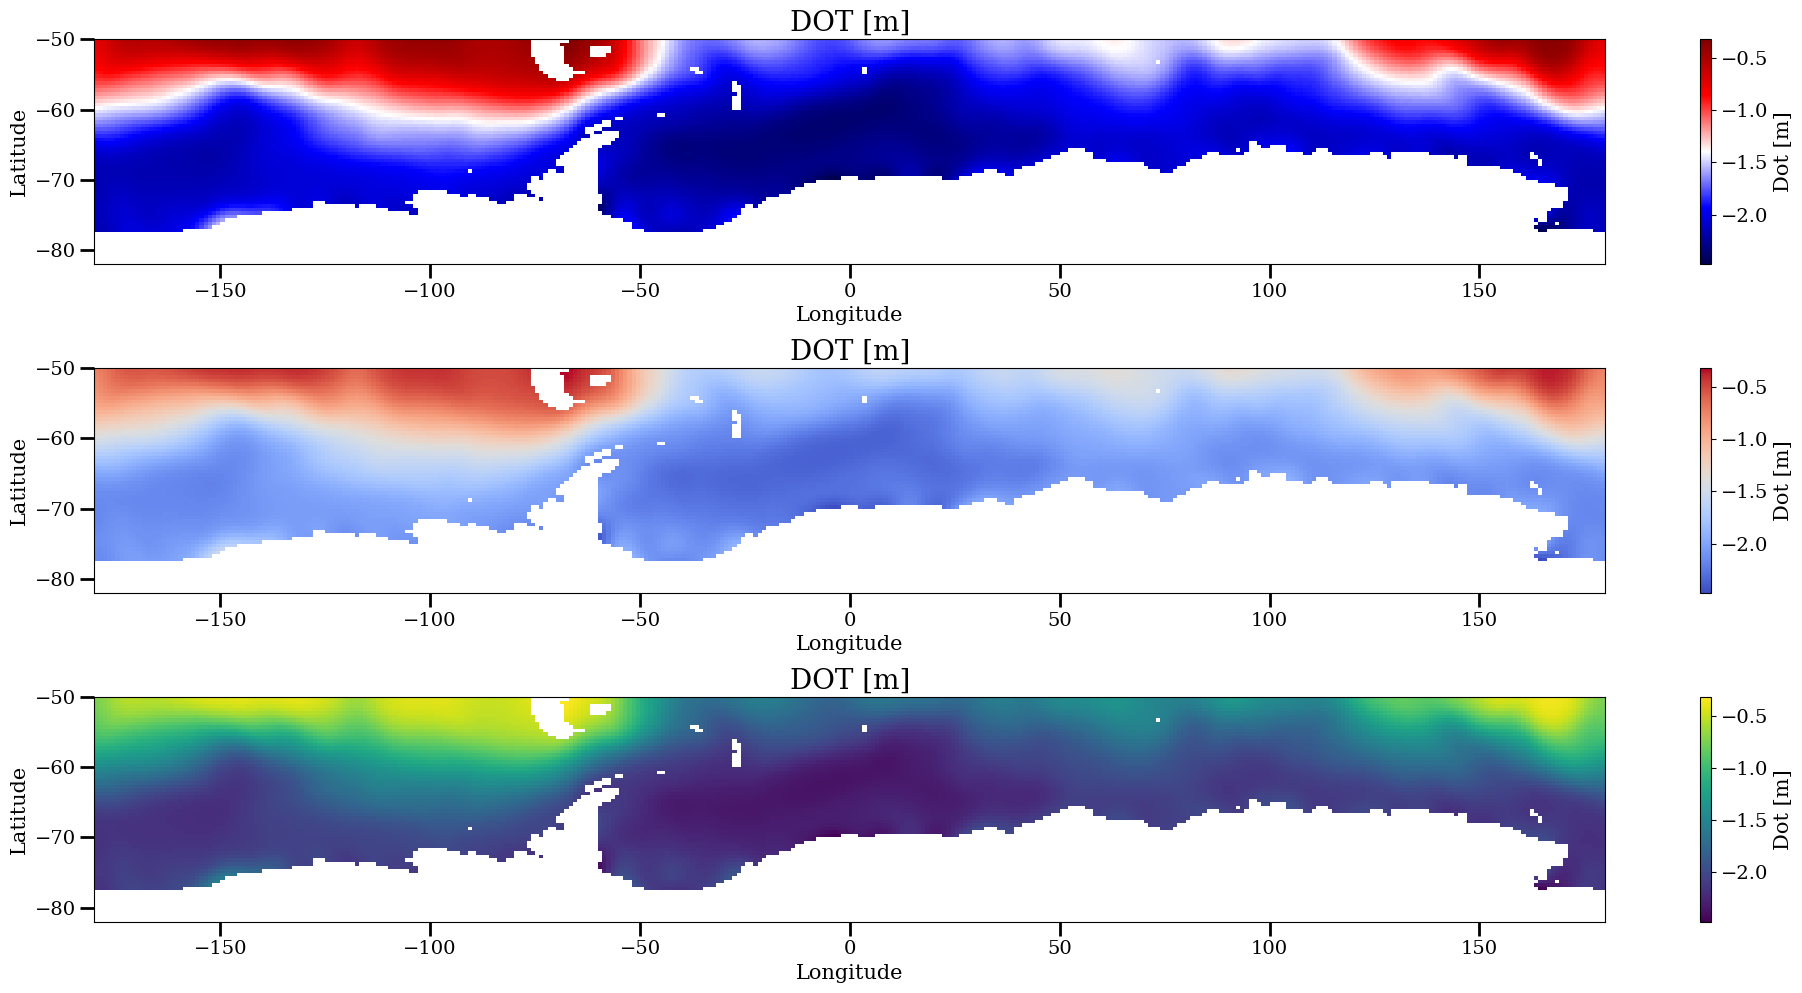

In [327]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

pc1 = axes[0].pcolormesh(llon_ij,llat_ij,dot[:,:,0], cmap='seismic')
axes[0].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[0].set_title('DOT [m]', fontsize=20)
axes[0].set_xlabel('Longitude', fontsize=15)
axes[0].set_ylabel('Latitude', fontsize=15)
cbar1 = fig.colorbar(pc1, ax=axes[0])
cbar1.set_label('Dot [m]', fontsize=15)
cbar1.ax.tick_params(labelsize=14)

pc2 = axes[1].pcolormesh(llon_ij,llat_ij,dot[:,:,0], cmap='coolwarm')
axes[1].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[1].set_title('DOT [m]', fontsize=20)
axes[1].set_xlabel('Longitude', fontsize=15)
axes[1].set_ylabel('Latitude', fontsize=15)
cbar2 = fig.colorbar(pc2, ax=axes[1])
cbar2.set_label('Dot [m]', fontsize=15)
cbar2.ax.tick_params(labelsize=14)

pc3 = axes[2].pcolormesh(llon_ij,llat_ij,dot[:,:,0], cmap='viridis')
axes[2].tick_params(axis='both', which='major', length=10, width=2, labelsize=14)
axes[2].set_title('DOT [m]', fontsize=20)
axes[2].set_xlabel('Longitude', fontsize=15)
axes[2].set_ylabel('Latitude', fontsize=15)
cbar3 = fig.colorbar(pc3, ax=axes[2])
cbar3.set_label('Dot [m]', fontsize=15)
cbar3.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

In [328]:
# select wind
u10 = era5_ds['u10'].values
v10 = era5_ds['v10'].values

print(seamask.shape)

u10 = u10*seamask[:,:, None]
v10 = v10*seamask[:,:, None]
U_air = np.sqrt(u10**2. + v10**2.)

print(u10.shape)

# wind stress
tau_x = rho_a*cd_aw*U_air*u10 #zonal wind
tau_y = rho_a*cd_aw*U_air*v10 #meridional wind

print('zonal wind:',  tau_x.shape)
print('meridional wind:', tau_y.shape)


(360, 64)
(360, 64, 193)
zonal wind: (360, 64, 193)
meridional wind: (360, 64, 193)


In [329]:
# Sea ice concentration (α)
alpha = sic_ds['cdr_seaice_conc_monthly'].values
alpha = np.clip(np.where(np.isnan(alpha), np.nan, alpha), 0, 1)
alpha_filled = np.where((np.isnan(alpha)) | (alpha < 0.15), 0.0, alpha) # cut off at alpha - 0.15 as this is the edge of the ice pack (ref this)

# Ice drift — raw values, NaN→0
u_ice_raw = np.nan_to_num(sid_ds.u_rotated.values * 1e-2, nan=0.0)
v_ice_raw = np.nan_to_num(sid_ds.v_rotated.values * 1e-2, nan=0.0)

# ── Smooth SID with same gaussian_filt as OSC (sig=3) ──────────────
u_ice = np.zeros_like(u_ice_raw)
v_ice = np.zeros_like(v_ice_raw)

for t in range(u_ice_raw.shape[2]):
    u_t     = u_ice_raw[:, :, t]
    v_t     = v_ice_raw[:, :, t]
    mask_t  = (u_t != 0.0).astype(float)

    u_smooth = ft.gaussian_filt(u_t,    sigma=3, mode='reflect')
    v_smooth = ft.gaussian_filt(v_t,    sigma=3, mode='reflect')
    weight   = ft.gaussian_filt(mask_t, sigma=3, mode='reflect')

    with np.errstate(invalid='ignore'):
        u_ice[:, :, t] = np.where(weight > 0.1, u_smooth / weight, 0.0)
        v_ice[:, :, t] = np.where(weight > 0.1, v_smooth / weight, 0.0)

# u_ice = u_ice_raw
# v_ice = v_ice_raw

u_ice = u_ice * seamask[:, :, None]
v_ice = v_ice * seamask[:, :, None]
U_ice = np.sqrt(u_ice**2 + v_ice**2)


tau_iw_x = rho_w * cd_iw * U_ice * u_ice
tau_iw_y = rho_w * cd_iw * U_ice * v_ice
tau_aw_x = tau_x
tau_aw_y = tau_y

oss_x = alpha_filled * tau_iw_x + (1 - alpha_filled) * tau_aw_x
oss_y = alpha_filled * tau_iw_y + (1 - alpha_filled) * tau_aw_y

seamask_nan = np.where(seamask == 1, 1.0, np.nan)
oss_x = oss_x * seamask_nan[:, :, None]
oss_y = oss_y * seamask_nan[:, :, None]

oss_x[0, :, :] = oss_x[-1, :, :]
oss_y[0, :, :] = oss_y[-1, :, :]

oss_x_filled = (xr.DataArray(oss_x, dims=("lon", "lat", "time"))
                .ffill("lon").bfill("lon").values)
oss_y_filled = (xr.DataArray(oss_y, dims=("lon", "lat", "time"))
                .ffill("lon").bfill("lon").values)

oss_x_filled = oss_x_filled * seamask_nan[:, :, None]
oss_y_filled = oss_y_filled * seamask_nan[:, :, None]

oss_mag = np.sqrt(oss_x_filled**2 + oss_y_filled**2)
print("OSS ready, shape:", oss_x_filled.shape)
print("OSS NaN fraction:", np.isnan(oss_x_filled[:,:,0]).mean())
print("OSS magnitude:", np.nanmax(np.abs(oss_x_filled)))

OSS ready, shape: (360, 64, 193)
OSS NaN fraction: 0.350390625
OSS magnitude: 0.288628472799264


In [330]:
print(np.nanmax(u_ice))
print(np.nanmax(v_ice))
print(np.nanmax(alpha))


print(oss_mag.shape)
print(tau_x.shape)

print(llat.min(), llat.max())   # should be ~ -82 to -50 (latitude range)
print(llon.min(), llon.max())   # should be ~ -180 to 180 (longitude range)

0.26137275530377807
0.17422628571000073
1.0
(360, 64, 193)
(360, 64, 193)
-81.75 -50.25
-179.5 179.5


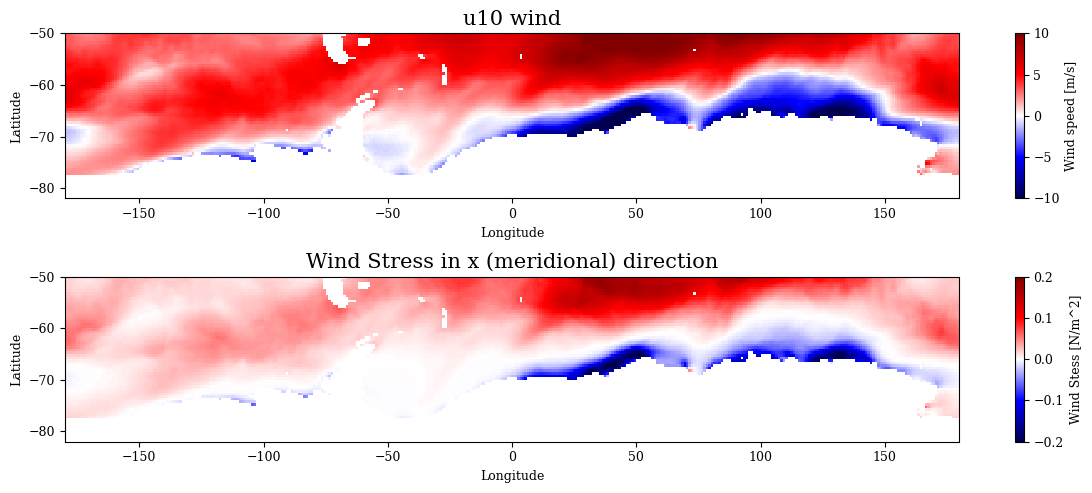

In [331]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon_ij, llat_ij, u10[:,:,0],cmap='seismic',vmin=-10,vmax=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('u10 wind', fontsize=15)
cbar1= plt.colorbar()
cbar1.set_label('Wind speed [m/s]')
plt.subplot(2,1,2)
plt.pcolormesh(llon_ij, llat_ij,tau_x[:,:,0],cmap='seismic',vmin=-0.2,vmax=0.2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Wind Stress in x (meridional) direction', fontsize=15)
cbar2= plt.colorbar()
cbar2.set_label('Wind Stess [N/m^2]')


plt.tight_layout()
plt.show()

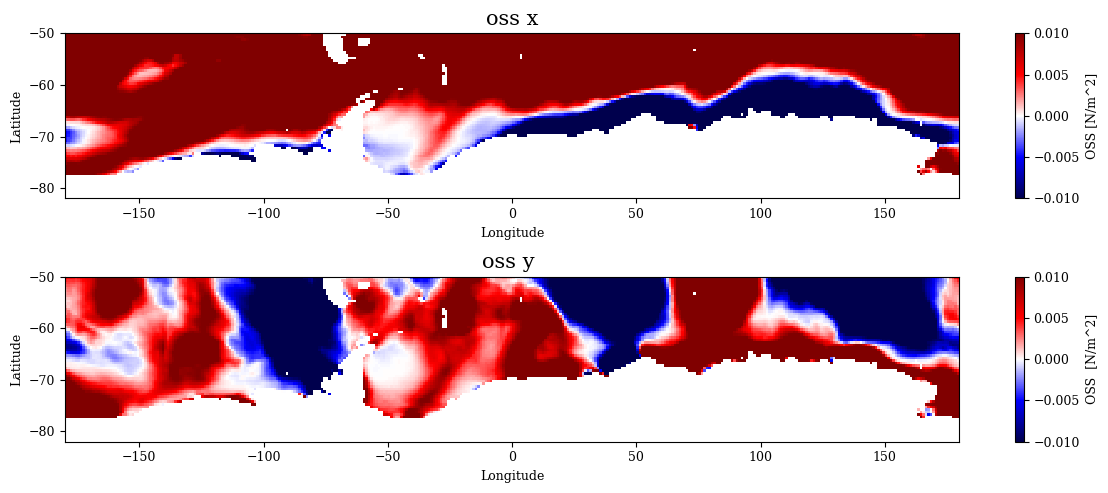

In [332]:
fig = plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
plt.pcolormesh(llon_ij, llat_ij, tau_x[:,:,0],cmap='seismic',vmin=-1e-2,vmax=1e-2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('oss x', fontsize=15)
cbar1= plt.colorbar()
cbar1.set_label('OSS [N/m^2]')
plt.subplot(2,1,2)
plt.pcolormesh(llon_ij, llat_ij,tau_y[:,:,0],cmap='seismic',vmin=-1e-2,vmax=1e-2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('oss y ', fontsize=15)
cbar2= plt.colorbar()
cbar2.set_label('OSS  [N/m^2]')


plt.tight_layout()
plt.show()

In [333]:
print(tau_x.shape)
print(tau_y.shape)
print(llon.shape)
print(llat.shape)
print(dot.shape)
print(oss_mag.shape)

(360, 64, 193)
(360, 64, 193)
(64, 360)
(64, 360)
(360, 64, 193)
(360, 64, 193)


In [334]:
print("lon size:", len(lon))        # expect 360
print("lat size:", len(lat))
print('llon_ij size:', (llon_ij.shape))
print('llat_ij size:', (llat_ij.shape))
print('llon: ', llon.shape)
print('llat: ', llat.shape)
print("tau_x shape:", tau_x.shape)  # (lon, lat, time)
print("dot shape:", dot.shape)
print("oss_x shape:", oss_x.shape)
print('tau_x shape:', tau_x.shape)

lon size: 360
lat size: 64
llon_ij size: (360, 64)
llat_ij size: (360, 64)
llon:  (64, 360)
llat:  (64, 360)
tau_x shape: (360, 64, 193)
dot shape: (360, 64, 193)
oss_x shape: (360, 64, 193)
tau_x shape: (360, 64, 193)


In [335]:
# WSC
ws_curl = np.zeros_like(tau_x)
for t in range(dot.shape[2]):
    dtaux_dx, dtaux_dy = grad_sphere(tau_x[:,:,t].T, llon, llat)
    dtauy_dx, dtauy_dy = grad_sphere(tau_y[:,:,t].T, llon, llat)
    ws_curl[:,:,t] = (dtauy_dx - dtaux_dy).T

ws_curl[~np.isfinite(ws_curl)] = np.nan
print("ws_curl shape:", ws_curl.shape)
print("ws_curl magnitude:", np.nanmax(np.abs(ws_curl)))

ws_curl shape: (360, 64, 193)
ws_curl magnitude: 2.464392928239705e-06


In [336]:
print(oss_x_filled.shape)
print(oss_y_filled.shape)
print(dot.shape)
print(ws_curl.shape)
print(llon.shape)
print(llat.shape)


(360, 64, 193)
(360, 64, 193)
(360, 64, 193)
(360, 64, 193)
(64, 360)
(64, 360)


In [337]:
os_curl = np.zeros_like(oss_x_filled)
for t in range(dot.shape[2]):
    dtaux_dx, dtaux_dy = grad_sphere(oss_x_filled[:,:,t].T, llon, llat)
    dtauy_dx, dtauy_dy = grad_sphere(oss_y_filled[:,:,t].T, llon, llat)
    os_curl[:,:,t] = (dtauy_dx - dtaux_dy).T

os_curl[~np.isfinite(os_curl)] = np.nan
print("os_curl shape:", os_curl.shape)
print("os_curl magnitude:", np.nanmax(np.abs(os_curl)))

os_curl shape: (360, 64, 193)
os_curl magnitude: 2.210942210786557e-06


In [338]:
# Clip extreme outliers before MCA — anything beyond 5 std is likely an artefact
osc_std = np.nanstd(os_curl)
os_curl_clipped = np.clip(os_curl, -5 * osc_std, 5 * osc_std)
print("After clipping max:", np.nanmax(np.abs(os_curl_clipped)))
# Should be ~4e-7

After clipping max: 4.753651227707307e-07


In [339]:
wsc_nan_mask = np.isnan(ws_curl[:, :, 0])
osc_nan_mask = np.isnan(os_curl[:, :, 0])

extra_nans = osc_nan_mask & ~wsc_nan_mask
print(f"Extra NaN points in osc not in wsc: {extra_nans.sum()}")

# Which variable is causing them?
print(f"NaNs in alpha t=0:  {np.isnan(alpha[:, :, 0]).sum()}")
print(f"NaNs in u_ice t=0:  {np.isnan(u_ice[:, :, 0]).sum()}")
print(f"NaNs in v_ice t=0:  {np.isnan(v_ice[:, :, 0]).sum()}")
print(f"NaNs in u10 t=0:    {np.isnan(u10[:, :, 0]).sum()}")
print(f"NaNs in v10 t=0:    {np.isnan(v10[:, :, 0]).sum()}")

Extra NaN points in osc not in wsc: 0
NaNs in alpha t=0:  7973
NaNs in u_ice t=0:  8073
NaNs in v_ice t=0:  8073
NaNs in u10 t=0:    8073
NaNs in v10 t=0:    8073


In [340]:
print(np.isnan(ws_curl[:,:,0]).sum(), "NaNs")
print(np.isinf(ws_curl[:,:,0]).sum(), "Infs")
print(np.nanmin(ws_curl[:,:,0]), np.nanmax(ws_curl[:,:,0]))
print(np.isnan(os_curl[:,:,0]).sum(), "NaNs")
print(np.isinf(os_curl[:,:,0]).sum(), "Infs")
print(np.nanmin(os_curl[:,:,1]),np.nanmax(os_curl[:,:,0]))
print(np.isnan(tau_x[:,:,0]).sum(), "NaNs in tau_x")
print(np.isnan(tau_y[:,:,0]).sum(), "NaNs in tau_y")


print(np.isinf(ws_curl).sum(), "Infs in ws_curl")   # should be 0
print(np.isinf(os_curl).sum(), "Infs in os_curl")   # should be 0
print(np.isnan(ws_curl[:,:,0]).sum(), "NaNs in ws_curl t=0")
print(np.isnan(os_curl[:,:,0]).sum(), "NaNs in os_curl t=0")

8641 NaNs
0 Infs
-1.7550045910229912e-06 1.2240370096574767e-06
8641 NaNs
0 Infs
-6.905708028130581e-07 9.022709565891481e-07
8073 NaNs in tau_x
8073 NaNs in tau_y
0 Infs in ws_curl
0 Infs in os_curl
8641 NaNs in ws_curl t=0
8641 NaNs in os_curl t=0


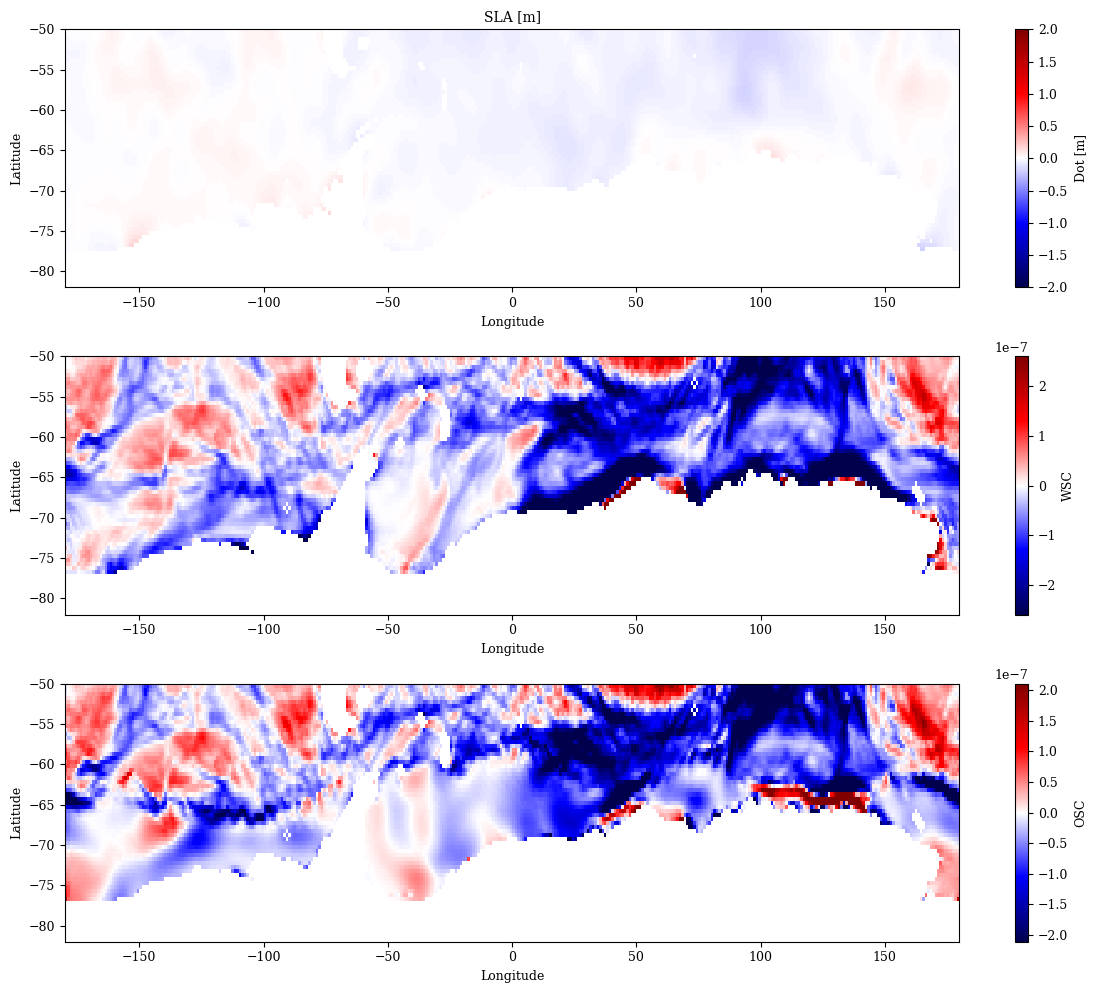

In [341]:
sla_fig = dot - np.nanmean(dot, axis=2, keepdims=True)

fig = plt.figure(figsize=(12,10))
plt.subplot(3,1,1)
plt.pcolormesh(llon_ij, llat_ij, sla_fig[:,:,0], vmin=-2, vmax=2, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SLA [m]', fontsize=10)
ws1bar = plt.colorbar()
ws1bar.set_label('Dot [m]')

vlim = np.nanpercentile(np.abs(ws_curl[:,:,0]), 95)  # robust to outliers
plt.subplot(3,1,2)
plt.pcolormesh(llon_ij, llat_ij, ws_curl[:,:,0], vmin=-vlim, vmax=vlim, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.quiver(llon, llat, u10[0], v10[0])
ws2bar = plt.colorbar()
ws2bar.set_label('WSC')

vlim = np.nanpercentile(np.abs(os_curl[:,:,0]), 95)  # robust to outliers
plt.subplot(3,1,3)
plt.pcolormesh(llon_ij, llat_ij, os_curl[:,:,0], vmin=-vlim, vmax=vlim, cmap='seismic')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.quiver(llon, llat, u10[0], v10[0])
ws3bar = plt.colorbar()
ws3bar.set_label('OSC')

plt.tight_layout()
plt.show()

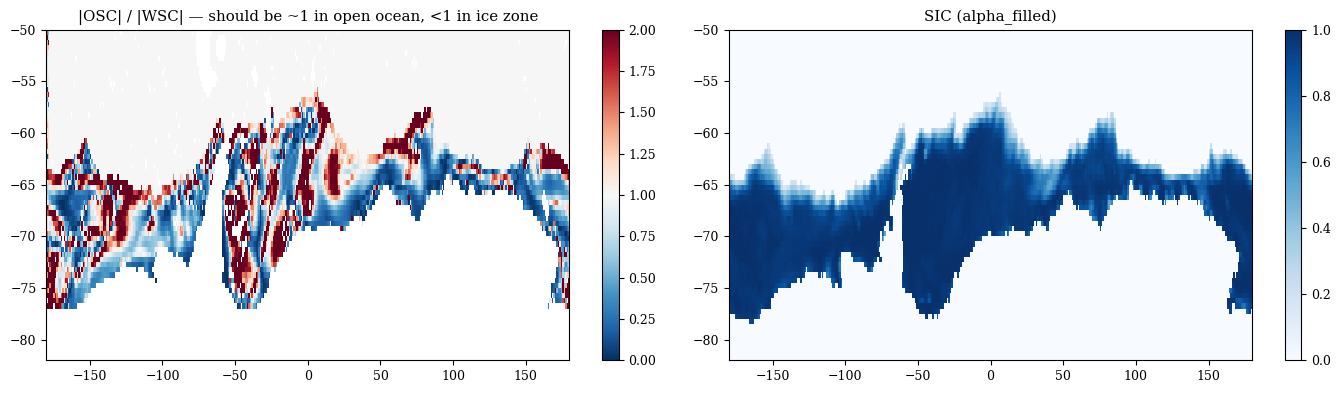

In [342]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

t = 0  # winter month — pick one with significant ice cover

# Ratio OSC/WSC — should be < 1 in ice zone, ~1 in open ocean
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.where(
        np.abs(ws_curl[:,:,t]) > 1e-9,
        np.abs(os_curl[:,:,t]) / np.abs(ws_curl[:,:,t]),
        np.nan
    )

im0 = axes[0].pcolormesh(llon_ij, llat_ij, ratio,
                          cmap='RdBu_r', vmin=0, vmax=2)
axes[0].set_title('|OSC| / |WSC| — should be ~1 in open ocean, <1 in ice zone')
plt.colorbar(im0, ax=axes[0])

# Alpha field for same timestep — ice extent
im1 = axes[1].pcolormesh(llon_ij, llat_ij, alpha_filled[:,:,t],
                          cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('SIC (alpha_filled)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

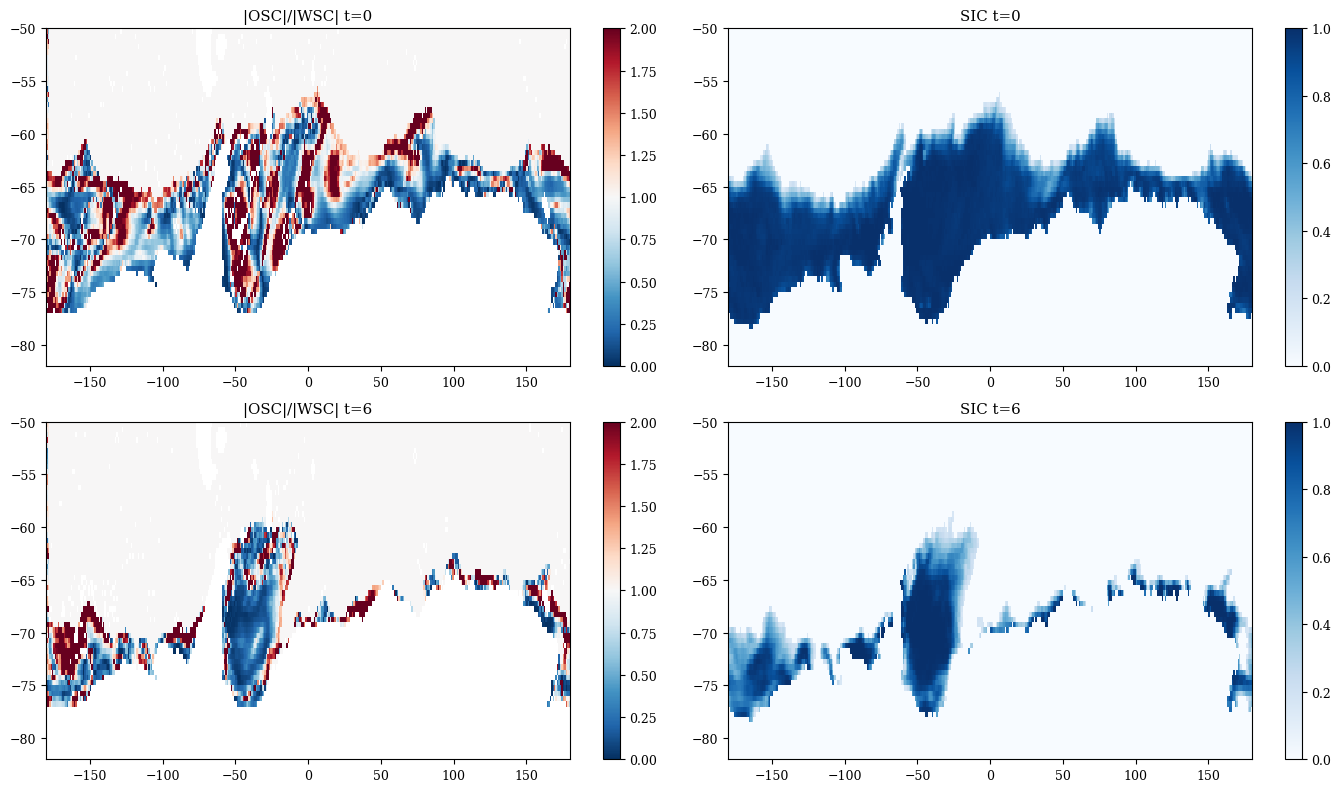

In [343]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, t in enumerate([0, 6]):  # adjust indices for summer/winter
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(
            np.abs(ws_curl[:,:,t]) > 1e-9,
            np.abs(os_curl[:,:,t]) / np.abs(ws_curl[:,:,t]),
            np.nan
        )
    im0 = axes[row,0].pcolormesh(llon_ij, llat_ij, ratio,
                                  cmap='RdBu_r', vmin=0, vmax=2)
    axes[row,0].set_title(f'|OSC|/|WSC| t={t}')
    plt.colorbar(im0, ax=axes[row,0])

    im1 = axes[row,1].pcolormesh(llon_ij, llat_ij, alpha_filled[:,:,t],
                                  cmap='Blues', vmin=0, vmax=1)
    axes[row,1].set_title(f'SIC t={t}')
    plt.colorbar(im1, ax=axes[row,1])

plt.tight_layout()
plt.show()

In [344]:
months = (dot_time.astype('datetime64[M]').astype(int) % 12 + 1)
print(months)

# 1. Remove time mean at every grid cell
sla = dot - np.nanmean(dot, axis=2, keepdims=True)
wsc_demeaned = ws_curl - np.nanmean(ws_curl, axis=2, keepdims=True)
osc_demeaned = os_curl_clipped - np.nanmean(os_curl_clipped, axis=2, keepdims=True)

# 2. Remove linear trend at every grid cell (on de-meaned data)
import pandas as pd
time_years = (pd.DatetimeIndex(dot_time).year
              + pd.DatetimeIndex(dot_time).month / 12.0).values

for name, field_in in [('sla', sla),
                        ('wsc', wsc_demeaned),
                        ('osc', osc_demeaned)]:
    arr = field_in.transpose(2, 0, 1)  # (time, lon, lat)
    n, slope, intercept, _, _, _ = linregress_3D_spatial_time(arr, time_years)
    trend = (slope[np.newaxis,:,:] * time_years[:,np.newaxis,np.newaxis]
             + intercept[np.newaxis,:,:])
    # detrended = arr - trend
    detrended = (arr - trend)
    detrended = detrended.transpose(1, 2, 0)  # back to (lon, lat, time)

    if name == 'sla': sla_detrended = detrended
    elif name == 'wsc': wsc_detrended = detrended
    elif name == 'osc': osc_detrended = detrended

# 3. Retain seasonal cycle (remove_seas = False))

remove_seas = False  # keep seasonal cycle as interested in this

if remove_seas:
    # Preallocate seasonal arrays
    sla_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)
    wsc_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)
    osc_seas = np.full((12, dot.shape[0], dot.shape[1]), np.nan)

    # Compute monthly climatology
    for m in range(1, 13):
        mask = (months == m)
        if np.any(mask):
            sla_seas[m-1] = np.nanmean(sla_detrended[:,:,mask], axis=2)
            wsc_seas[m-1] = np.nanmean(wsc_detrended[:,:,mask], axis=2)
            osc_seas[m-1] = np.nanmean(osc_detrended[:,:,mask], axis=2)

    # Remove seasonality
    sla_final = np.zeros_like(sla_detrended)
    wsc_final = np.zeros_like(wsc_detrended)
    osc_final = np.zeros_like(osc_detrended)
    for i, m in enumerate(months):
        sla_final[:,:,i] = sla_detrended[:,:,i] - sla_seas[m-1]
        wsc_final[:,:,i] = wsc_detrended[:,:,i] - wsc_seas[m-1]
        osc_final[:,:,i] = osc_detrended[:,:,i] - osc_seas[m-1]

    print("Seasonal cycle removed.")

else:
    sla_final = sla_detrended.copy()
    wsc_final = wsc_detrended.copy()
    osc_final = osc_detrended.copy()

    print("Seasonal cycle retained.")



[ 7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6
  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9 11 12  2  3  4  6  7  8  9
 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9
 10 11 12  1  2  3  4  5  6  7  8  9 10 11 12  1  2  3  4  5  6  7  8  9
 10]
Seasonal cycle retained.


In [345]:

print(dot.shape)
print(sla_final.shape)
print(ws_curl.shape)
print(wsc_final.shape)
print(os_curl.shape)
print(osc_final.shape)


# print(dot[1])
# print(dot[2])

(360, 64, 193)
(360, 64, 193)
(360, 64, 193)
(360, 64, 193)
(360, 64, 193)
(360, 64, 193)


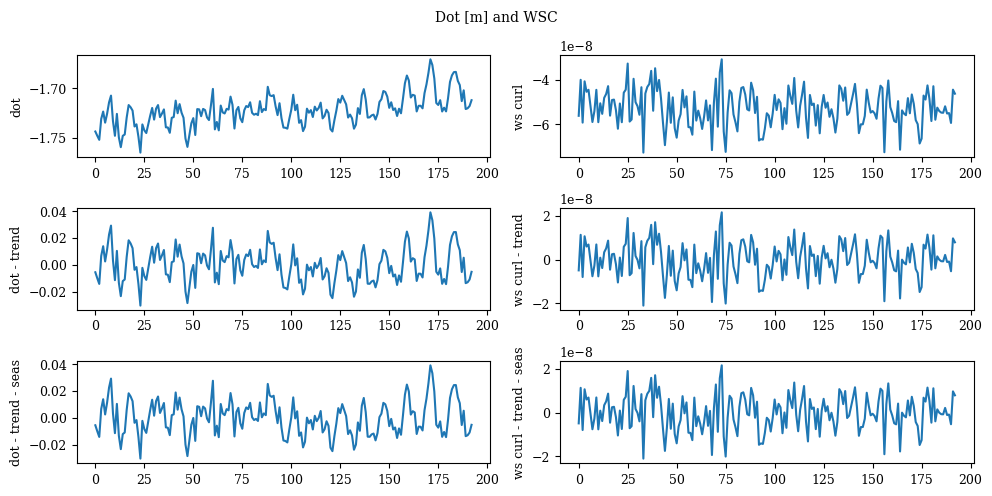

In [346]:
fig = plt.figure(figsize=(10,5))
plt.subplot(3,2,1)
plt.plot(np.nanmean(dot, axis=(0,1)))
plt.ylabel('dot')
plt.subplot(3,2,2)
plt.plot(np.nanmean(ws_curl, axis=(0,1)))
plt.ylabel('ws curl')
plt.subplot(3,2,3)
plt.plot(np.nanmean(sla_detrended, axis=(0,1)))
plt.ylabel('dot - trend')
plt.subplot(3,2,4)
plt.plot(np.nanmean(wsc_detrended, axis=(0,1)))
plt.ylabel('ws curl - trend')
plt.subplot(3,2,5)
plt.plot(np.nanmean(sla_final, axis=(0,1)))
plt.ylabel('dot - trend - seas')
plt.subplot(3,2,6)
plt.plot(np.nanmean(wsc_final, axis=(0,1)))
plt.ylabel('ws curl - trend - seas')
plt.suptitle('Dot [m] and WSC', fontsize=10)

plt.tight_layout()
plt.show()

In [347]:
print(sla_final.shape)

(360, 64, 193)


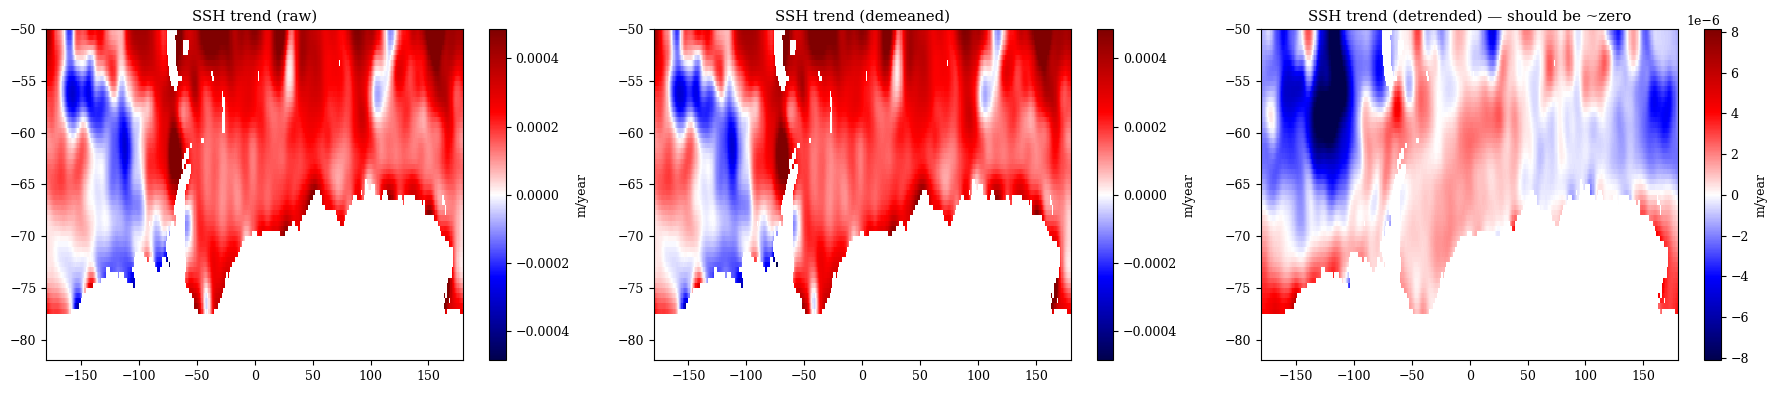

In [348]:
# # SSH trends without removing ocean variability due to wind stress curl
# plt.figure(figsize=(10,3))
# n, slope, intercept, p_val, r_square, rmse = linregress_3D(dot_detrended.transpose(2, 0, 1))
# plt.pcolormesh(lon, lat, slope.T, cmap='seismic')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.title('SSH Slope after removing the trend')
# cbar = plt.colorbar()
# cbar.set_label('Trend')
# plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Raw SSH trend — what the trend looks like
n, slope_raw, intercept, p_val, _, _ = linregress_3D(dot.transpose(2, 0, 1))
vlim = np.nanpercentile(np.abs(slope_raw), 98)
im0 = axes[0].pcolormesh(lon, lat, slope_raw.T, cmap='seismic', vmin=-vlim, vmax=vlim)
axes[0].set_title('SSH trend (raw)')
plt.colorbar(im0, ax=axes[0], label='m/year')

# 2. Demeaned SSH trend — confirms mean removal didn't affect trend
n, slope_dm, _, _, _, _ = linregress_3D(sla.transpose(2, 0, 1))
vlim = np.nanpercentile(np.abs(slope_dm), 98)
im1 = axes[1].pcolormesh(lon, lat, slope_dm.T, cmap='seismic', vmin=-vlim, vmax=vlim)
axes[1].set_title('SSH trend (demeaned)')
plt.colorbar(im1, ax=axes[1], label='m/year')

# 3. Detrended SSH trend — should be ~zero everywhere (confirms detrending worked)
n, slope_det, _, _, _, _ = linregress_3D(sla_detrended.transpose(2, 0, 1))
vlim = np.nanpercentile(np.abs(slope_det), 98)
im2 = axes[2].pcolormesh(lon, lat, slope_det.T, cmap='seismic', vmin=-vlim, vmax=vlim)
axes[2].set_title('SSH trend (detrended) — should be ~zero')
plt.colorbar(im2, ax=axes[2], label='m/year')

plt.tight_layout()
plt.show()


In [349]:
# MCA

In [350]:
# dot[bad_month_mask[0:-13]] = np.nan
# ws_curl[bad_month_mask[0:-13]] = np.nan
# dot = dot * seamask
# ws_curl = ws_curl * seamask
#
# joint_mask = ~np.isnan(dot) & ~np.isnan(ws_curl)
# joint_mask = np.all(joint_mask, axis=0)   # collapse time → (lat, lon)
#
# dot = dot[:, joint_mask]
# ws_curl = ws_curl[:, joint_mask]
#
# # dot_xa = xr.DataArray(dot, dims=("time", "feature"))
# # ws_curl_xa = xr.DataArray(ws_curl, dims=("time", "feature"))
# #
#
# dot_xa = xr.DataArray(dot_final, coords=[time_dot, lat, lon], dims=["time", "lon", "lat"],)
# ws_curl_xa = xr.DataArray(ws_curl_final, coords=[time_dot, lat, lon], dims=["time", "lon", "lat"],)

In [351]:
# good_time = ~bad_month_mask[:-13]   # align with dot/era window if needed
#
# dot_final = dot_final[good_time]
# ws_curl_final = ws_curl_final[good_time]
# time_dot = time_dot[good_time]
# months   = months[good_time]
#
# joint_mask = ~np.isnan(dot_final) & ~np.isnan(wsc_final)
# joint_mask = np.all(joint_mask, axis=2)  # (lat, lon)
#
# lat2d, lon2d = np.meshgrid(lat, lon, indexing='ij')
# lat_flat = lat2d[joint_mask]
# lon_flat = lon2d[joint_mask]
#
# feature_index = pd.MultiIndex.from_arrays(
#     [lat_flat, lon_flat],
#     names=("lat", "lon")
# )
#
# dot_final = dot_final[:, joint_mask]
# wsc_final = wsc_final[:, joint_mask]
#
# # dot_xa = xr.DataArray(dot, dims=("time", "feature"), coords={"time": time_dot, "feature": np.arange(dot.shape[1])})
# # ws_curl_xa = xr.DataArray(ws_curl, dims=("time", "feature"), coords={"time": time_dot, "feature": np.arange(ws_curl.shape[1])})
#
# dot_xa = xr.DataArray(
#     dot,
#     dims=("time", "feature"),
#     coords={"time": dot_time, "feature": feature_index}
# )
#
# wsc_xa = xr.DataArray(
#     wsc_final,
#     dims=("time", "feature"),
#     coords={"time": dot_time, "feature": feature_index}
# )

sla_xa = xr.DataArray(
    sla_final.transpose(2, 1, 0),          # (time, lat, lon)
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'sla'
)

wsc_xa = xr.DataArray(
    wsc_final.transpose(2, 1, 0),          # (time, lat, lon)
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'wsc'
)

osc_xa = xr.DataArray(
    osc_final.transpose(2,1,0),
    dims=("time", "lat", "lon"),
    coords={"time": dot_time, "lat": lat, "lon": lon},
    name = 'osc'
)

# osc_xa = xr.DataArray(
#     os_curl_smooth.transpose(2,1,0),
#     dims=("time", "lat", "lon"),
#     coords={"time": dot_time, "lat": lat, "lon": lon},
#     name = 'osc'
# )





In [352]:
total_nans = sla_xa.isnull().sum().item()
print(f"Total NaN values in dot_xa: {total_nans}")

total_nans_wsc = wsc_xa.isnull().sum().item()
print(f"Total NaN values in wsc: {total_nans_wsc}")

total_nans_osc = osc_xa.isnull().sum().item()
print(f"Total NaN values in osc: {total_nans_osc}")


total_points_wsc = wsc_xa.size
print(f"Total data points in wsc: {total_points_wsc}")

total_points_osc = osc_xa.size
print(f"Total data points in osc_xa: {total_points_osc}")

total_points_sla = sla_xa.size
print(f"Total data points in sla_xa: {total_points_sla}")

Total NaN values in dot_xa: 1558089
Total NaN values in wsc: 1667713
Total NaN values in osc: 1667713
Total data points in wsc: 4446720
Total data points in osc_xa: 4446720
Total data points in sla_xa: 4446720


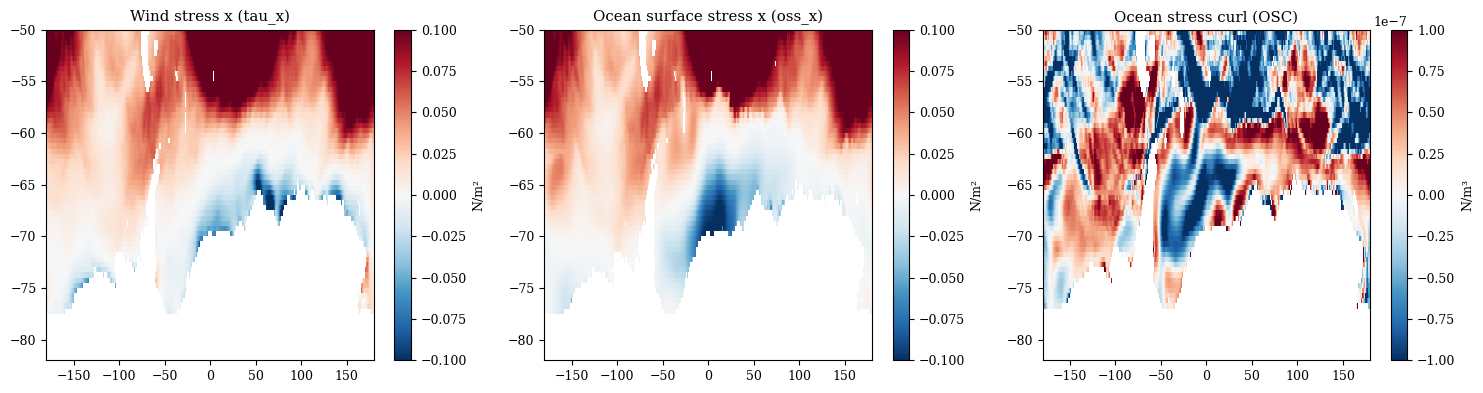

Max tau_x (wind stress): 0.398503205253155
Max oss_x (ocean surface stress): 0.288628472799264
Max osc (curl): 2.210942210786557e-06
Max ws_curl: 2.464392928239705e-06
Ratio oss_x/tau_x: 0.7242814336108251


In [353]:
t = 50  # month index
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].pcolormesh(llon_ij, llat_ij, tau_x[:,:,t], cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[0].set_title('Wind stress x (tau_x)')
plt.colorbar(im0, ax=axes[0], label='N/m²')

im1 = axes[1].pcolormesh(llon_ij, llat_ij, oss_x_filled[:,:,t], cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[1].set_title('Ocean surface stress x (oss_x)')
plt.colorbar(im1, ax=axes[1], label='N/m²')

im2 = axes[2].pcolormesh(llon_ij, llat_ij, osc_final[:,:,t], cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
axes[2].set_title('Ocean stress curl (OSC)')
plt.colorbar(im2, ax=axes[2], label='N/m³')

plt.tight_layout()
plt.show()

# Magnitude checks
print("Max tau_x (wind stress):",       np.nanmax(np.abs(tau_x)))
print("Max oss_x (ocean surface stress):", np.nanmax(np.abs(oss_x_filled)))
print("Max osc (curl):",                np.nanmax(np.abs(os_curl)))
print("Max ws_curl:",                   np.nanmax(np.abs(ws_curl)))
print("Ratio oss_x/tau_x:",            np.nanmax(np.abs(oss_x_filled)) / np.nanmax(np.abs(tau_x)))

NaN fraction in oss_x (region): 0.309
SIC range in region: 0.0 1.0
alpha_filled range: 0.0 1.0


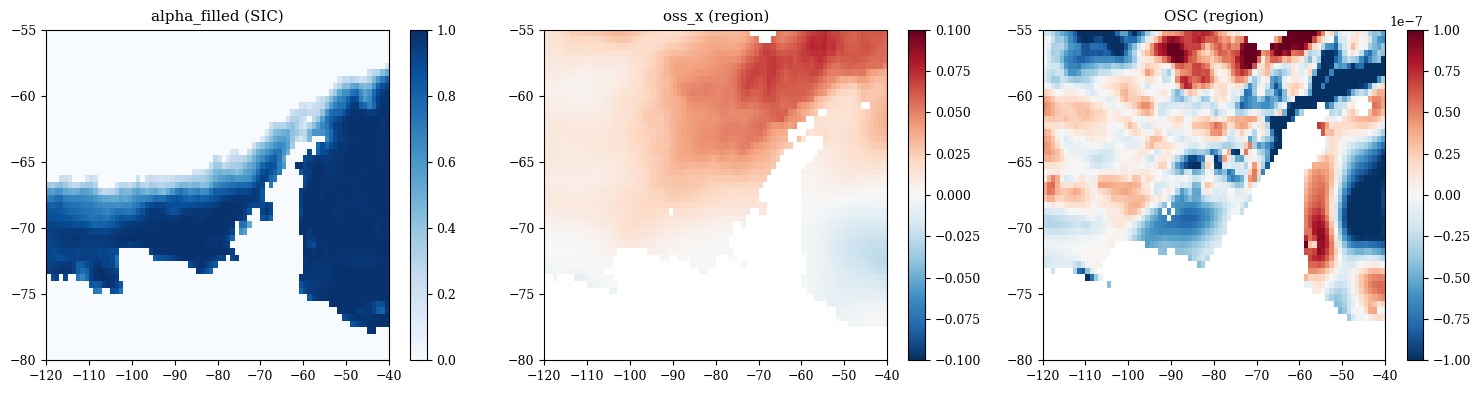

In [354]:
# Zoom into the problematic region
lon_mask = (lon >= -120) & (lon <= -40)
lat_mask = (lat >= -80) & (lat <= -55)

oss_region = oss_x_filled[np.ix_(lon_mask, lat_mask, [50])]
alpha_region = alpha_filled[np.ix_(lon_mask, lat_mask, [50])]
sic_region = alpha[np.ix_(lon_mask, lat_mask, [50])]

print("NaN fraction in oss_x (region):", np.isnan(oss_region).mean())
print("SIC range in region:", np.nanmin(sic_region), np.nanmax(sic_region))
print("alpha_filled range:", np.nanmin(alpha_region), np.nanmax(alpha_region))

# Plot zoom
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
lon_r = lon[lon_mask]
lat_r = lat[lat_mask]
llon_r, llat_r = np.meshgrid(lon_r, lat_r, indexing='ij')

im0 = axes[0].pcolormesh(llon_r, llat_r, alpha_filled[np.ix_(lon_mask, lat_mask, [50])][:,:,0],
                          cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('alpha_filled (SIC)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(llon_r, llat_r, oss_x_filled[np.ix_(lon_mask, lat_mask, [50])][:,:,0],
                          cmap='RdBu_r', vmin=-0.1, vmax=0.1)
axes[1].set_title('oss_x (region)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(llon_r, llat_r, os_curl[np.ix_(lon_mask, lat_mask, [50])][:,:,0],
                          cmap='RdBu_r', vmin=-1e-7, vmax=1e-7)
axes[2].set_title('OSC (region)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

In [355]:
# common_mask = (~dot_xa.isnull()) & (~ws_curl_xa.isnull())
# dot_xa = dot_xa.where(common_mask).dropna(dim=('time','lon','lat'), how='any')
# ws_curl_xa = ws_curl_xa.where(common_mask).dropna(dim=('time','lon','lat'), how='any')

# dot_xa = dot_xa.dropna(dim='lon', how='any')
# dot_xa = dot_xa.dropna(dim='lat', how='any')
#
# ws_curl_xa = ws_curl_xa.dropna(dim='lon', how='any')
# ws_curl_xa = ws_curl_xa.dropna(dim='lat', how='any')



In [356]:
import numpy as np

# Latitude weights — same sqrt(cos(lat)) as the EOF script
coslat  = np.cos(np.deg2rad(lat)).clip(0., 1.)
weights = np.sqrt(coslat)   # shape (lat,)

# Broadcast to (lat, lon) to match xarray spatial dims
weights_2d = xr.DataArray(
    np.broadcast_to(weights[:, np.newaxis], (len(lat), len(lon))),
    dims=('lat', 'lon')
)

In [357]:
import inspect

# var_1 = osc_xa
# var_2 = sla_xa

var_1 = sla_xa
var_2 = osc_xa

var_1_name = var_1.name.upper()
var_2_name = var_2.name.upper()

# model = xe.cross.MCA(n_modes=22, standardize=False, use_coslat= True)
# model.fit(var_1, var_2, dim='time')

model = xe.cross.MCA(n_modes=22, standardize=False, use_coslat = True)
model.fit(var_1, var_2, dim='time')

print(sla_xa.coords)

print(dir(model))
print(var_1.dims)
print(var_2.dims)


comps1, comps2 = model.components()  # Singular vectors (spatial patterns)
scores1, scores2 = model.scores()  # Expansion coefficients (temporal patterns)

Coordinates:
  * time     (time) datetime64[ns] 2kB 2002-07-01 2002-08-01 ... 2018-10-01
  * lat      (lat) float64 512B -81.75 -81.25 -80.75 ... -51.25 -50.75 -50.25
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
['__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_augment_data', '_check_parameter_number', '_compute_cross_covariance_diagonal_numpy', '_compute_cross_covariance_numpy', '_compute_cross_matrix', '_compute_total_squared_covariance', '_compute_total_variance', '_covariance_explained_DC95', '_decomposer_kwargs', '_deserialize_attrs', '_fit_algorithm', '_get_components', '_get_scores', '_in

In [358]:
# how many spatial points are fully valid across all timesteps?
valid_1 = (~np.isnan(var_1)).all(dim='time')
valid_2 = (~np.isnan(var_2)).all(dim='time')
valid_both = valid_1 & valid_2

print(f"Valid {var_1} points:", valid_1.sum().item())
print(f"Valid {var_2} points:", valid_2.sum().item())
print("Valid in both:", valid_both.sum().item())  # this is what xeofs sees

# check what grad_sphere actually receives
t = 0
field = tau_x[:,:,t]
print("field shape:", field.shape)
print("llon shape:", llon.shape)
print("llat shape:", llat.shape)
print("llon values sample:", llon[:,0])   # should be -179.5 to 179.5 (longitude)
print("llat values sample:", llat[0,:])   # should be -81.75 to -50.25 (latitude)
print("costheta min:", np.cos(llat * np.pi/180).min())
print("costheta max:", np.cos(llat * np.pi/180).max())

# check lon differences used in df_dx
print("llon col diffs sample:", (llon[:,2:] - llon[:,:-2])[0,:5])  # should be ~2.0

Valid <xarray.DataArray 'sla' (time: 193, lat: 64, lon: 360)> Size: 36MB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [ 1.77649687e-02,  2.03420102e-02,  2.18290506e-02, ...,
          6.37830504e-03,  1.06148431e-02,  1.44622667e-02],
        [ 2.39381575e-02,  2.74320174e-02,  2.97535766e-02, ...,
          9.70192459e-03,  1.48847732e-02,  1.96892624e-02],
        [ 2.75139482e-02,  3.15622817e-02,  3.43919468e-02, ...,
          1.15727473e-02,  1.73180374e-02,  2.26954498e-02]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,     

In [359]:
s1 = scores1.values; s2 = scores2.values
c1 = comps1.values; c2 = comps2.values

In [360]:
# Full path to the 'results' directory
results_dir = os.path.join(path, 'Oana/', 'results')

# Check if the directory already exists
if os.path.exists(results_dir):
    print("Directory already exists")
else:
    # Create the directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    print("Directory created!")

Directory already exists


In [361]:

# write PCs on files


# fname = path + 'results/PCs_dot_' + gridtype + '.txt'
# fname = path + 'results/PCs_dot_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(dot_time)):
#         file.write(f'{dot_time[i]}\t{s1[0,i]}\t{s1[1,i]}\t{s1[2,i]}\n')
# file.close()
#
# # fname = path + 'results/PCs_ws_curl_' + gridtype + '.txt'
# fname = path + 'results/PCs_ws_curl_' + gridtype + '_seas.txt'
# with open(fname, 'w') as file:
#     file.write('time\tPC1\tPC2\tPC3\n')
#     for i in range(len(dot_time)):
#         file.write(f'{dot_time[i]}\t{s2[0,i]}\t{s2[1,i]}\t{s2[2,i]}\n')
# file.close()

In [362]:
r_pears = []; p_pears = []
r_spear = []; p_spear = []
for m in range(1,6):
    x = scores1.sel(mode=m)
    y = scores2.sel(mode=m)
    r, p = scipy.stats.pearsonr(x, y)
    r_pears.append(np.round(r, 2)); p_pears.append(np.round(p, 2))
    r, p = scipy.stats.spearmanr(x, y)
    r_spear.append(np.round(r, 2)); p_spear.append(np.round(p, 2))

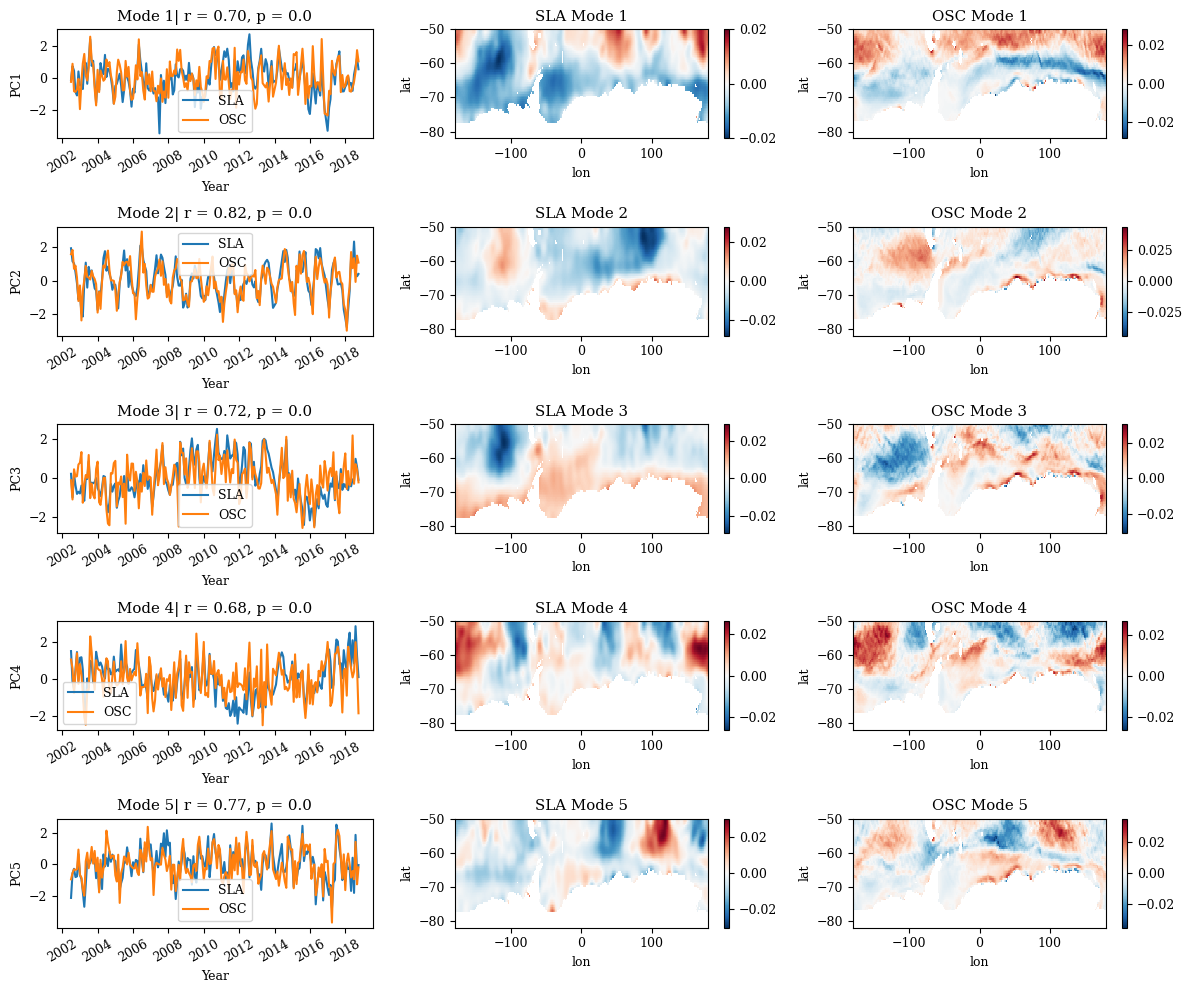

In [363]:
fig = plt.figure(figsize=(12,10))

for i in range(0,5):
    j = 3*i+1

    mode_num = i+1
    # --- TIME SERIES ---
    ax = plt.subplot(5,3,j)

    # Normalise the scores for the time series plot
    s1_norm = scores1.sel(mode=mode_num) / scores1.sel(mode=mode_num).std()
    s2_norm = scores2.sel(mode=mode_num) / scores2.sel(mode=mode_num).std()

    # scores1.sel(mode=i+1).plot(label=f'{var_1_name}')
    # scores2.sel(mode=i+1).plot(label=f'{var_2_name}')

    s1_norm.plot(label=f'{var_1_name}')
    s2_norm.plot(label=f'{var_2_name}')

    ax.set_title(f'Mode {i+1}| r = {r_pears[i]:.2f}, p = {p_pears[i]}')
    ax.set_xlabel('Year')
    ax.set_ylabel(f'PC{i+1}')
    ax.tick_params(axis = 'x', rotation=30)
    ax.legend()

    ax2 = plt.subplot(5,3,j+1)
    comps1.sel(mode = i+1).plot(ax = ax2, cmap='RdBu_r')
    ax2.set_title(f'{var_1_name} Mode {i+1}')

    ax3 = plt.subplot(5,3,j+2)
    comps2.sel(mode = i+1).plot(ax = ax3, cmap='RdBu_r')
    ax3.set_title(f'{var_2_name} Mode {i+1}')

fig.tight_layout()
plt.show()
# fig.savefig(save_dir + 'old_ds_to_2018' )

In [364]:
result = model.heterogeneous_patterns()
print(type(result), len(result))
print(type(result[0]))

<class 'tuple'> 2
<class 'tuple'>


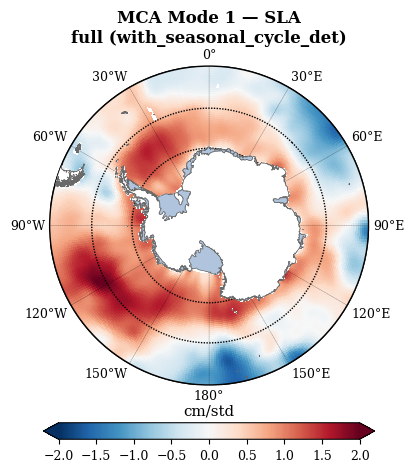

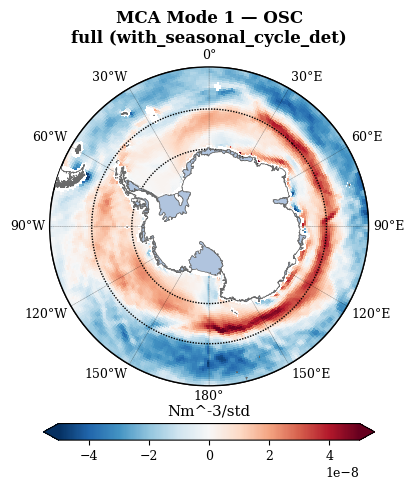

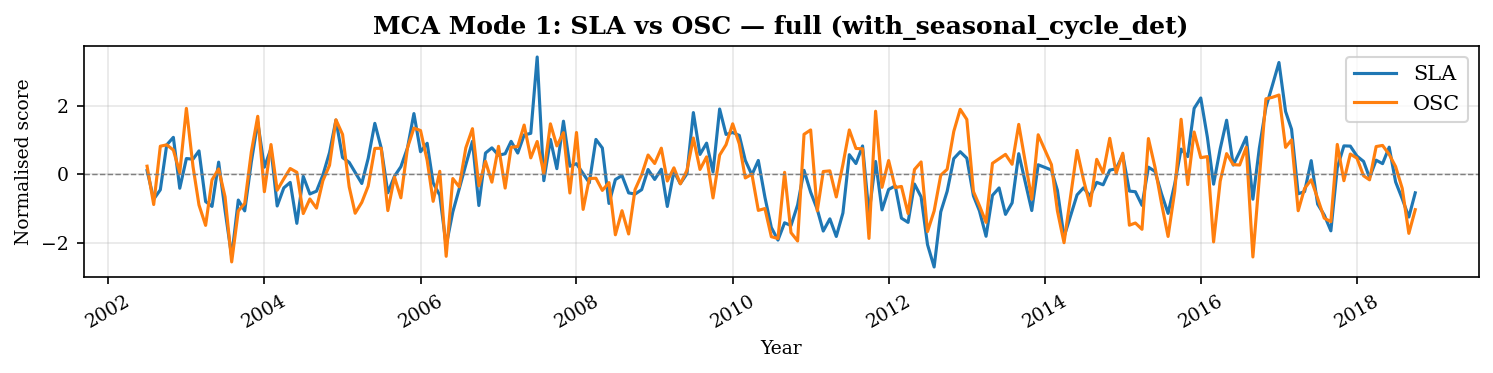

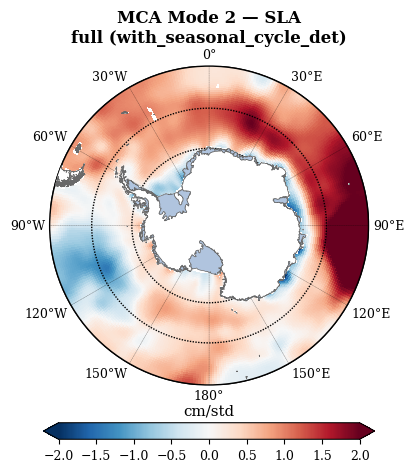

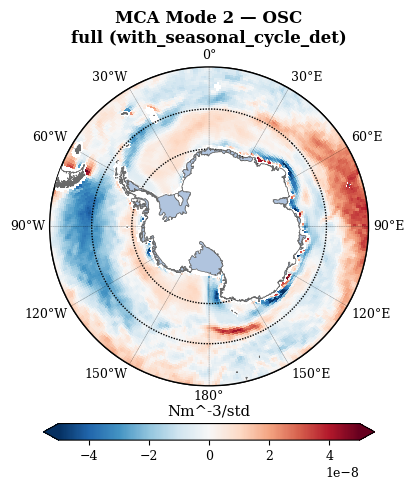

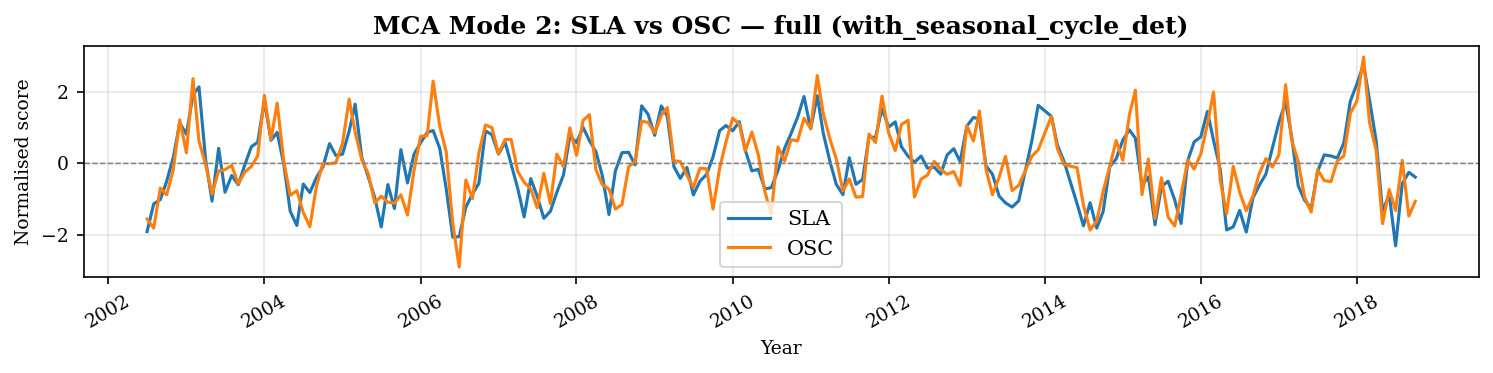

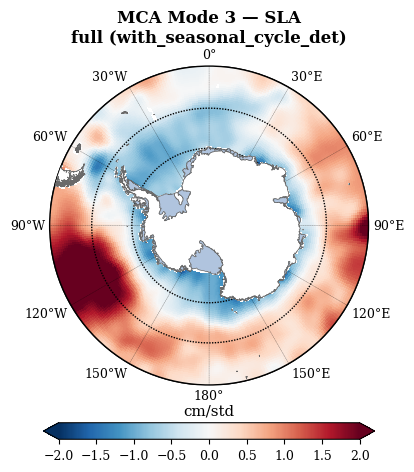

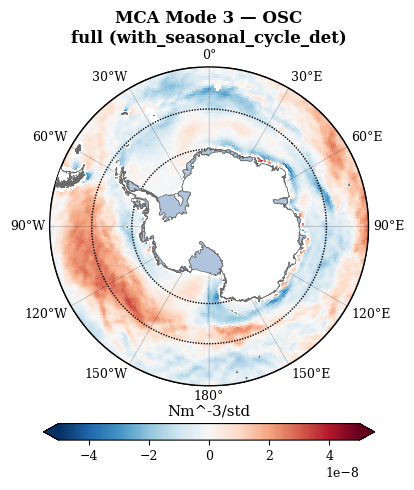

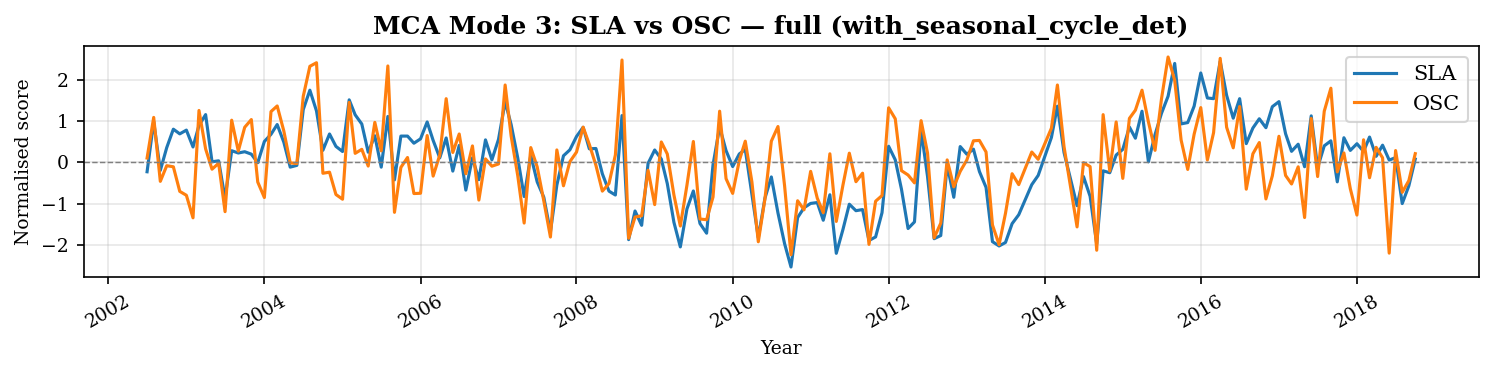

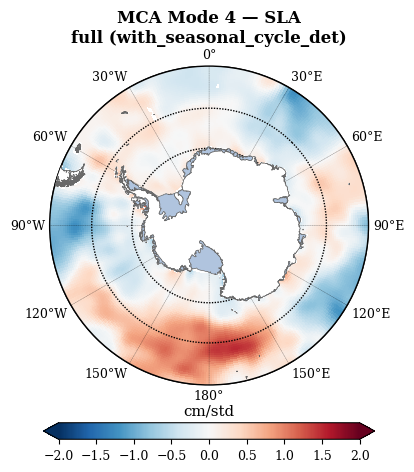

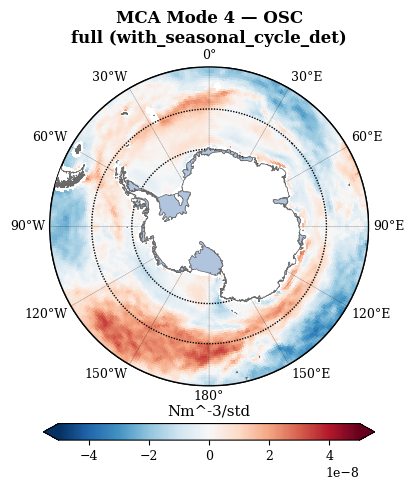

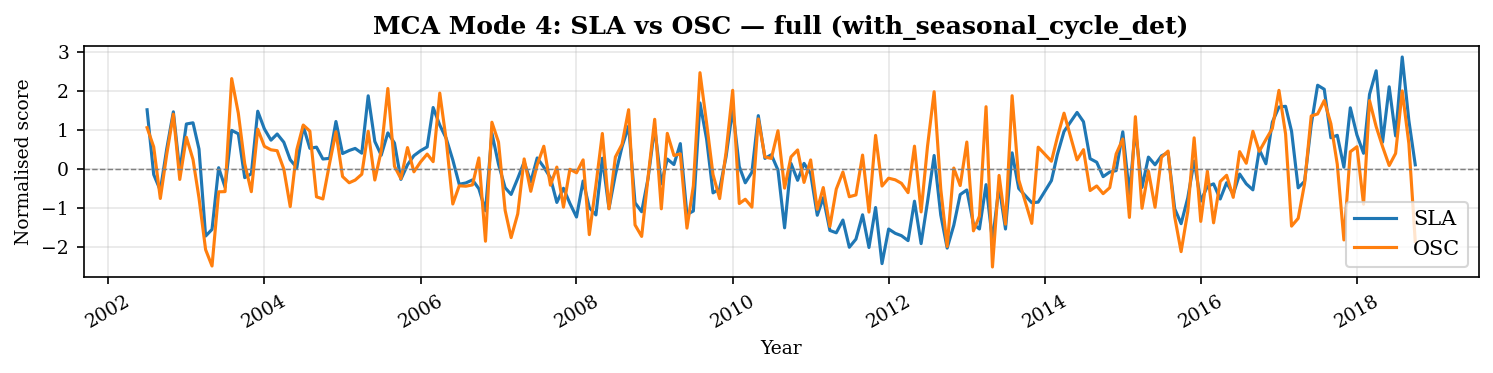

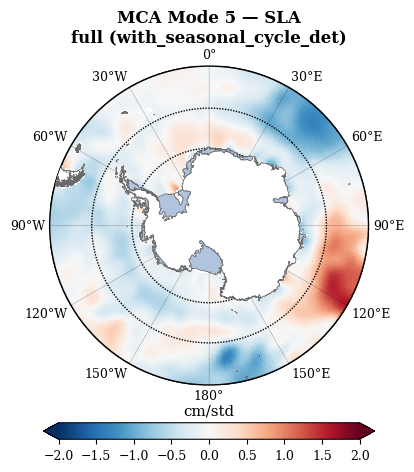

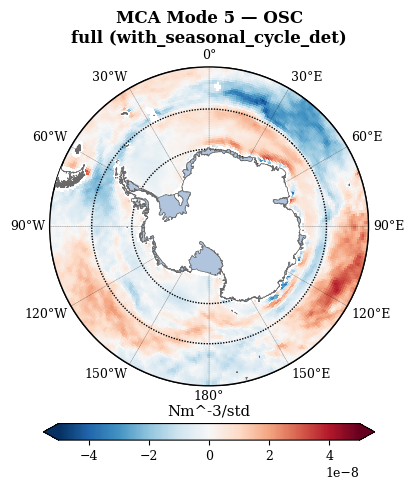

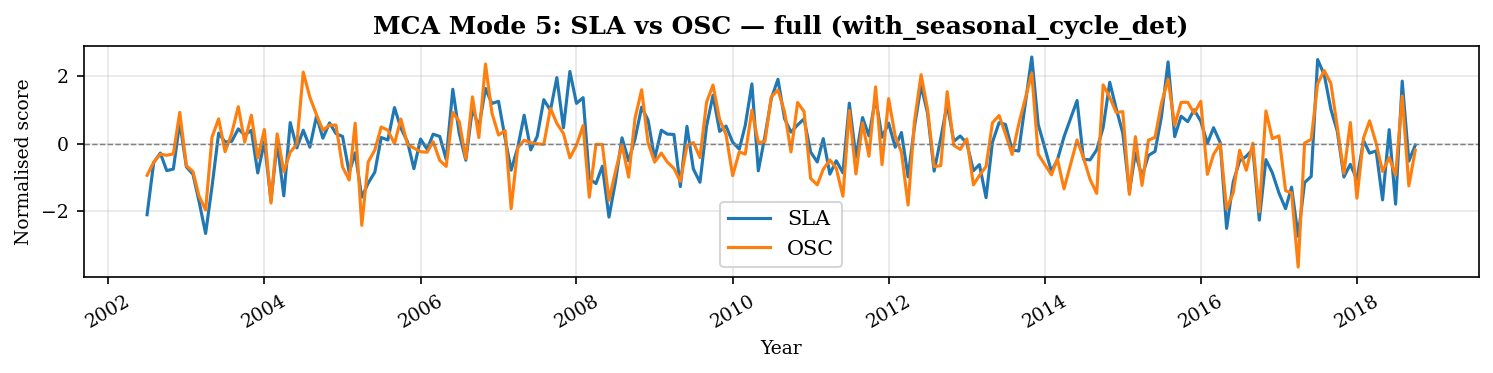

In [365]:
import aux_stereoplot as st
sector_name = 'full'
detrended = True

suffix  = 'deseas' if remove_seas else 'with_seasonal_cycle'
suffix += '_det'   if detrended else '_raw'

n_modes = 5

# Get raw components (singular vectors, dimensionless)
comps1, comps2 = model.components()
scores1, scores2 = model.scores()

# # ── Manual sign flip to match reference paper ──────────────────────
# flip_both = flip all four outputs (comps1, comps2, scores1, scores2)
# flip_osc  = flip only OSC side (comps2, scores2) — pattern ok, relative sign wrong
flip_both = [1,2,3]  # modes where both fields need flipping
flip_osc  = []             # modes where only OSC side needs flipping

for mode_num in flip_both:
    comps1.loc[dict(mode=mode_num)]  *= -1
    comps2.loc[dict(mode=mode_num)]  *= -1
    scores1.loc[dict(mode=mode_num)] *= -1
    scores2.loc[dict(mode=mode_num)] *= -1

for mode_num in flip_osc:
    comps2.loc[dict(mode=mode_num)]  *= -1
    scores2.loc[dict(mode=mode_num)] *= -1

for mode_num in range(1, n_modes + 1):

    # Scale spatial patterns by std of the corresponding PC score
    # This preserves original units when reconstructed
    comp1_m = (comps1.sel(mode=mode_num) * scores1.sel(mode=mode_num).std().item())*100
    comp2_m = (comps2.sel(mode=mode_num) * scores2.sel(mode=mode_num).std().item())

    # Normalise the scores for the time series plot
    s1_norm = scores1.sel(mode=mode_num) / scores1.sel(mode=mode_num).std()
    s2_norm = scores2.sel(mode=mode_num) / scores2.sel(mode=mode_num).std()

    maxabs_1 = float(np.nanpercentile(np.abs(comp1_m.values), 99))
    maxabs_2 = float(np.nanpercentile(np.abs(comp2_m.values), 99))
    vlims_1 = [-maxabs_1, maxabs_1]
    vlims_2 = [-maxabs_2, maxabs_2]

    vlims_2 = [-0.5e-7, 0.5e-7]
    vlims_1 = [-2, 2]

    # --- Grid + wrap for stereo plotting ---
    lons = comp1_m.lon.values
    lats = comp1_m.lat.values

    llon_w1, llat_w1, comp1_wrapped = st.wrap_lon_for_plot(comp1_m.values, lons, lats)
    llon_w2, llat_w2, comp2_wrapped = st.wrap_lon_for_plot(comp2_m.values, lons, lats)

    # ============================
    # FIGURE 1 — Stereo var_1
    # ============================
    fig1, ax1, _ = st.spstere_plot(
        llon_w1, llat_w1, comp1_wrapped,
        vlims_1, 'RdBu_r',  'cm/std', bcolor=None
    )
    fig1.tight_layout(rect=[0, 0, 1, 0.93])
    fig1.suptitle(
        f'MCA Mode {mode_num} — {var_1_name}\n{sector_name} ({suffix})',
        fontsize=12, fontweight='bold'
    )

    # ============================
    # FIGURE 2 — Stereo var_2
    # ============================
    fig2, ax2, _ = st.spstere_plot(
        llon_w2, llat_w2, comp2_wrapped,
        vlims_2, 'RdBu_r', 'Nm^-3/std', bcolor=None
    )
    fig2.tight_layout(rect=[0, 0, 1, 0.93])
    fig2.suptitle(
        f'MCA Mode {mode_num} — {var_2_name}\n{sector_name} ({suffix})',
        fontsize=12, fontweight='bold'
    )

    # ============================
    # FIGURE 3 — Timeseries
    # ============================
    # s1_norm = s1 / s1.std()
    # s2_norm = s2 / s2.std()

    fig3, ax3 = plt.subplots(figsize=(12, 2), dpi=150)
    ax3.plot(s1_norm.time, s1_norm, label=var_1_name, linewidth=1.5)
    ax3.plot(s2_norm.time, s2_norm, label=var_2_name, linewidth=1.5)
    ax3.axhline(0, color='grey', linewidth=0.7, linestyle='--')

    ax3.set_xlabel('Year')
    ax3.set_ylabel('Normalised score')
    ax3.set_title(
        f'MCA Mode {mode_num}: {var_1_name} vs {var_2_name} — {sector_name} ({suffix})',
        fontsize=12, fontweight='bold'
    )
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=30)

    plt.show()


In [366]:
# compute squared covariance fraction (equivalent to explained variance in PCA)
sq_cov_frac = model.squared_covariance_fraction()
scf = sq_cov_frac.values
cum_sum = np.cumsum(scf)
print('Cumulative sum of squares:', cum_sum)
print('Squared covariance fraction:',scf)

Cumulative sum of squares: [0.336337   0.65482539 0.79659675 0.84131371 0.88486159 0.90731063
 0.92690312 0.9382994  0.94882052 0.95542143 0.96128155 0.96601755
 0.96989394 0.97313116 0.97594872 0.97850208 0.98084249 0.9828752
 0.98455775 0.98611102 0.98738136 0.98863197]
Squared covariance fraction: [0.336337   0.31848839 0.14177136 0.04471696 0.04354789 0.02244903
 0.01959249 0.01139629 0.01052111 0.00660091 0.00586012 0.004736
 0.0038764  0.00323721 0.00281756 0.00255336 0.00234041 0.0020327
 0.00168256 0.00155327 0.00127033 0.00125061]


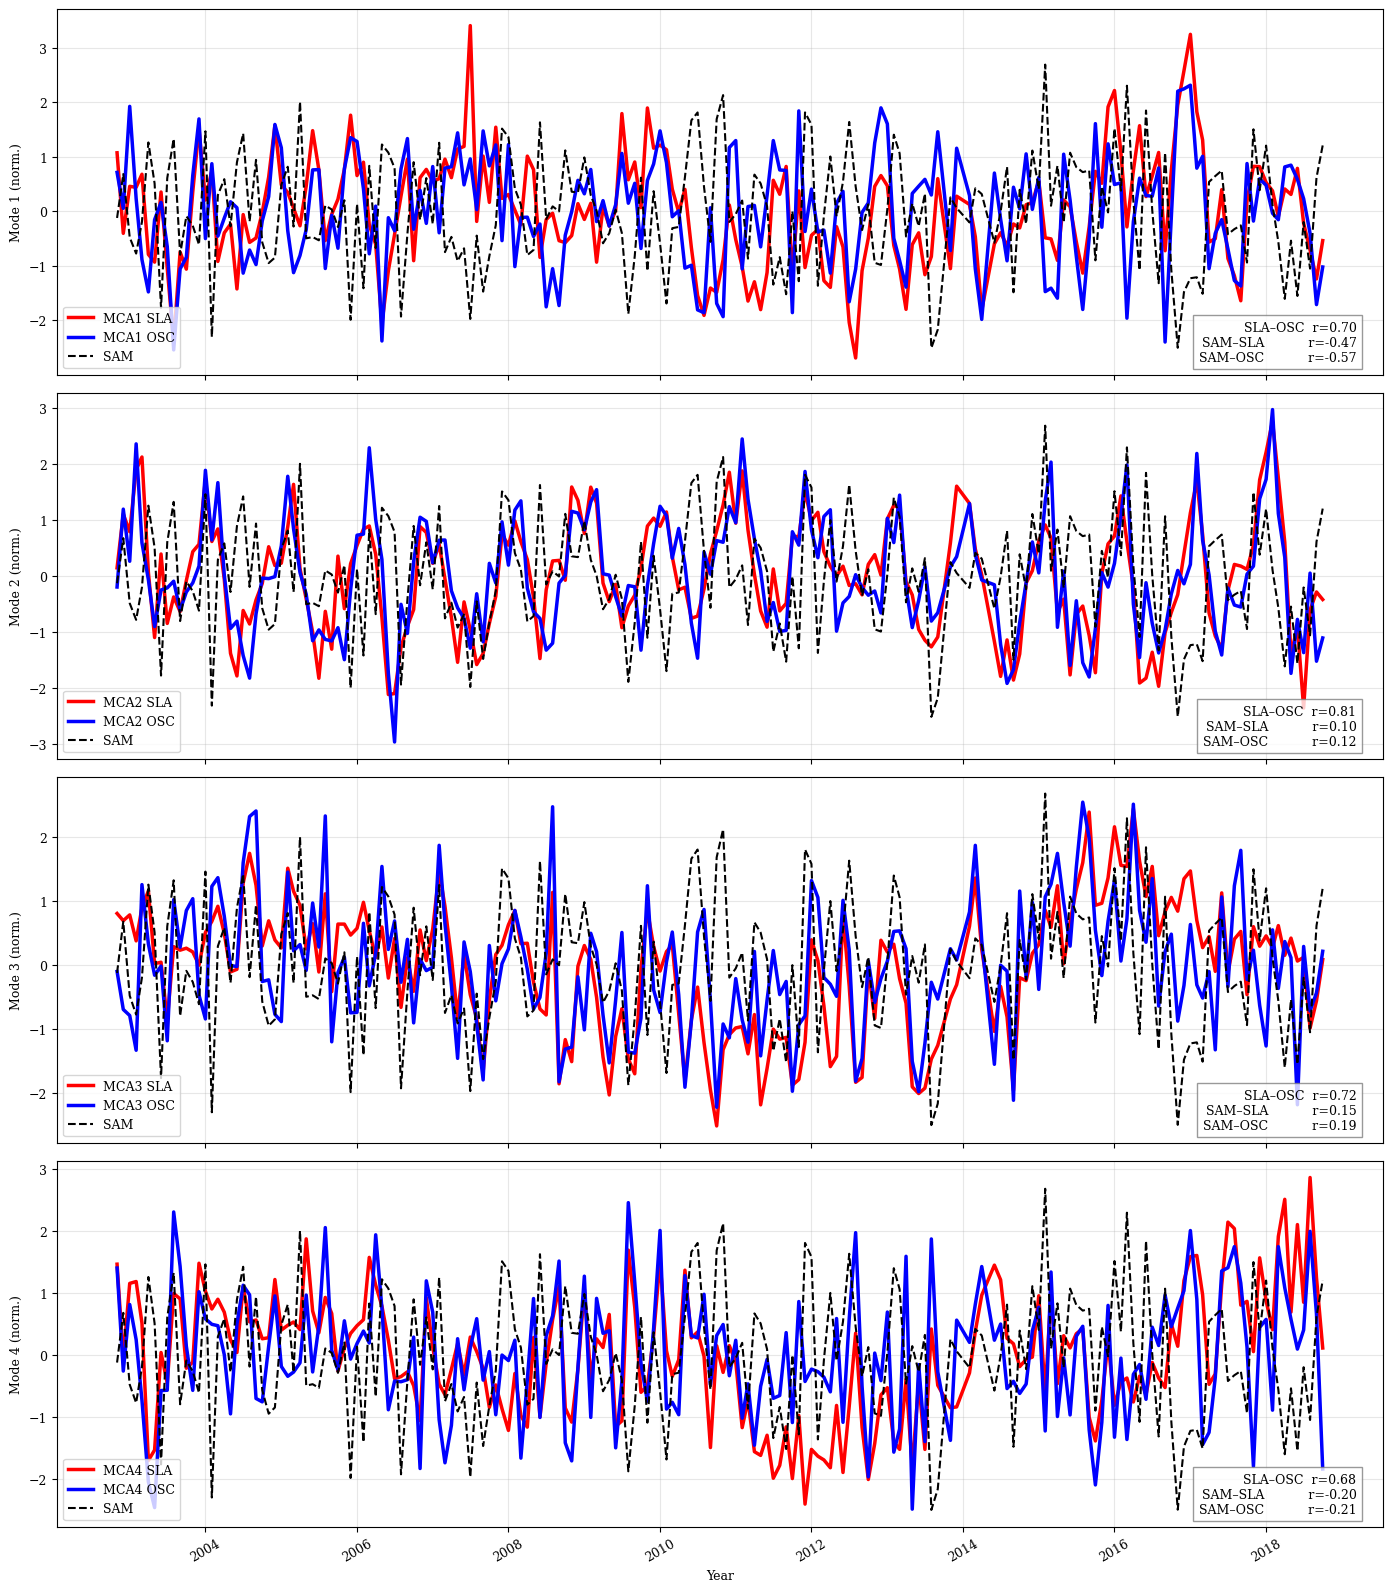

In [367]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
sam_ds  = xr.open_dataset(clim_dir + 'SAM/sam_2000_2024.nc')
sam_da  = sam_ds["SAM"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(sam_da.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

# index_da   = sam_da.sel(time=common_time)
# index_norm = (index_da - index_da.mean()) / index_da.std()

ref_start = '2002-11'
ref_end   = '2018-10'

# Select full period for plotting
index_da = sam_da.sel(time=common_time)

# Detrend over reference period first
index_ref = index_da.sel(time=slice(ref_start, ref_end))

t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

# Apply detrend fit to the FULL time series (using same slope/intercept)
t_full       = np.arange(len(index_da))
trend_full   = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

# Standardise using reference period mean and std
ref_mean = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std  = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='SAM')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'SAM–{var_1_name}           r={r_i1:.2f}\n'
        f'SAM–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

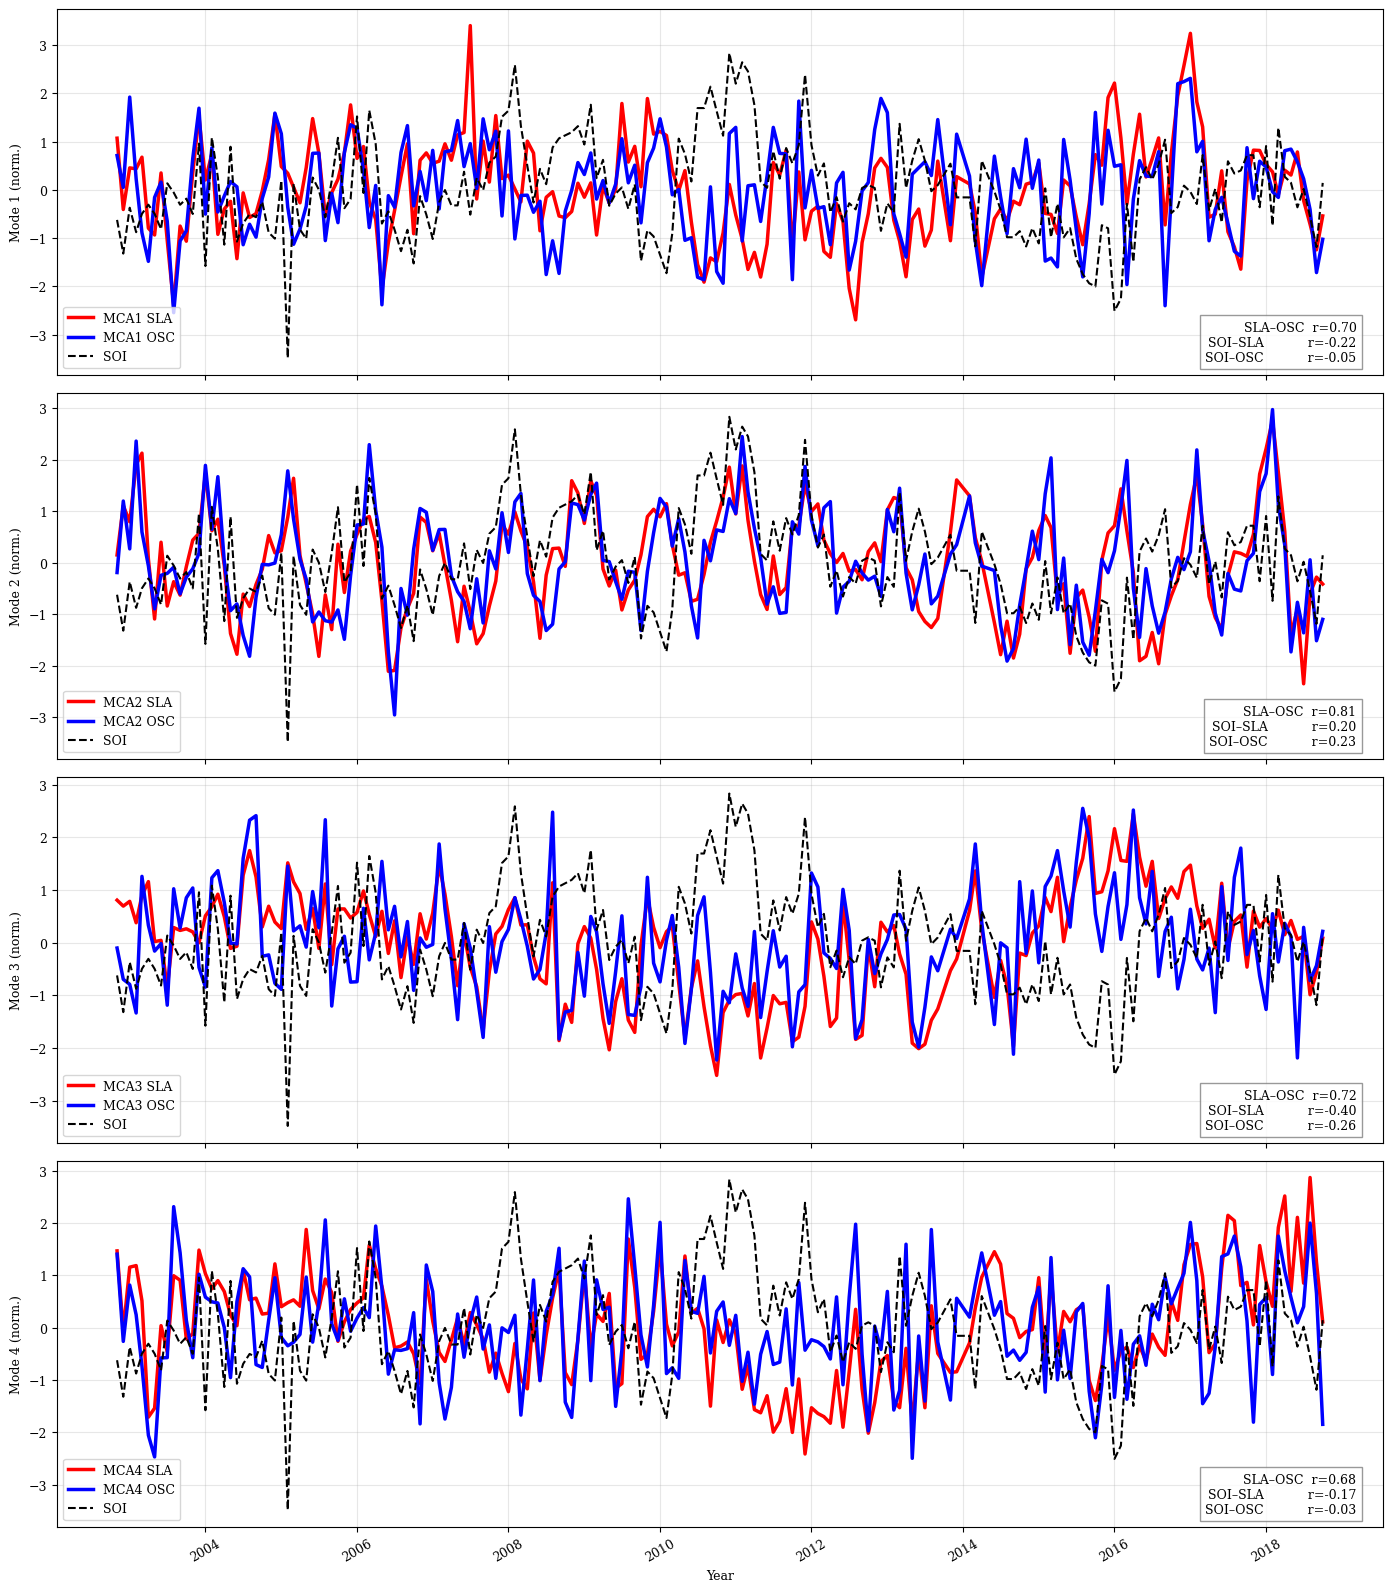

In [376]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
soi_ds  = xr.open_dataset(clim_dir + 'SOI/soi_2000_2024.nc')
soi_da  = soi_ds["SOI"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(soi_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

# index_da   = soi_da.sel(time=common_time)
# index_norm = (index_da - index_da.mean()) / index_da.std()

ref_start = '2002-11'
ref_end   = '2018-10'

# Select full period for plotting
index_da = soi_da.sel(time=common_time)

# Detrend over reference period first
index_ref = index_da.sel(time=slice(ref_start, ref_end))

t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

# Apply detrend fit to the FULL time series (using same slope/intercept)
t_full       = np.arange(len(index_da))
trend_full   = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

# Standardise using reference period mean and std
ref_mean = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std  = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='SOI')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'SOI–{var_1_name}           r={r_i1:.2f}\n'
        f'SOI–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

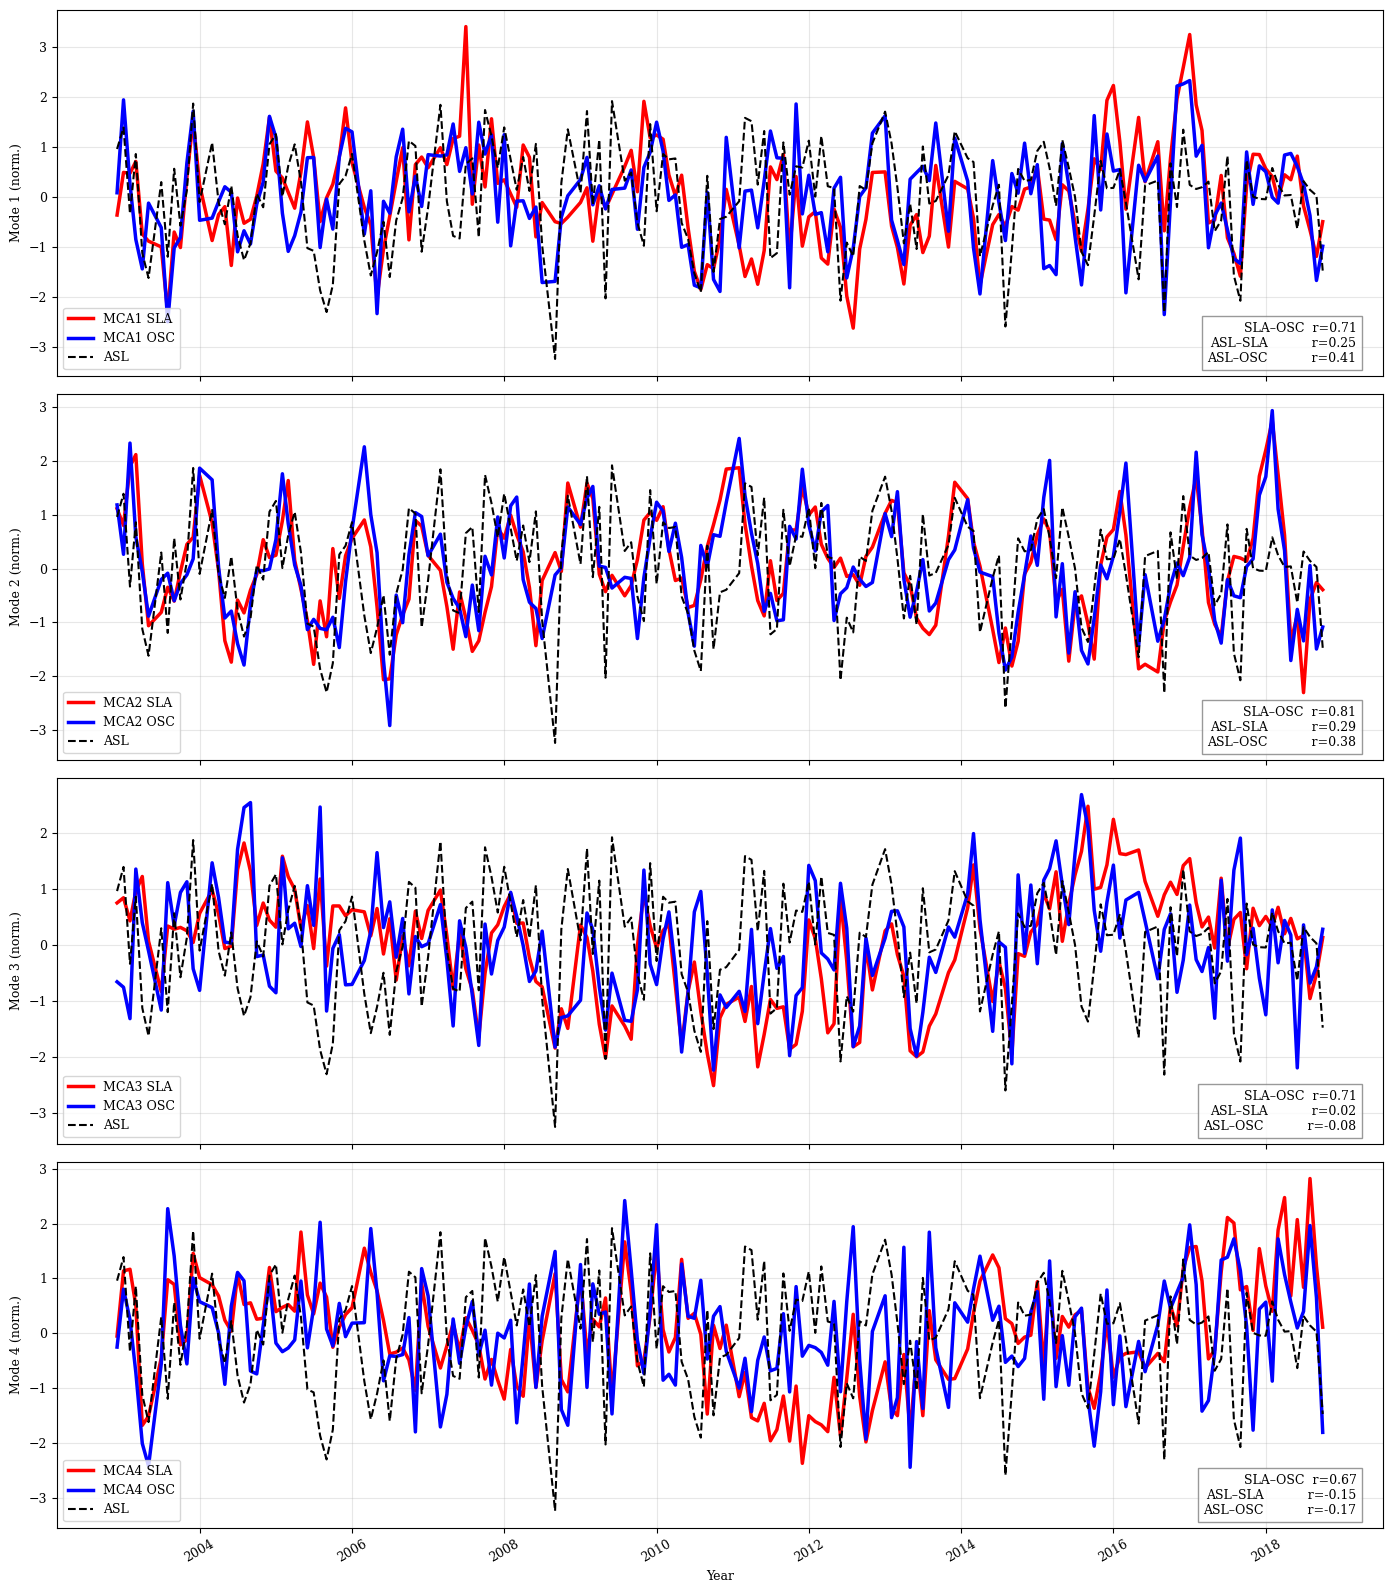

In [377]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align ALS ──────────────────────────────────────────────────────
asl_ds  = xr.open_dataset(clim_dir + 'ASL/ASL_2000_2025_data.nc')
asl_da  = asl_ds["RelCenPres"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(asl_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

# index_da   = asl_da.sel(time=common_time)
# index_norm = (index_da - index_da.mean()) / index_da.std()

ref_start = '2002-11'
ref_end   = '2018-10'

# Select full period for plotting
index_da = asl_da.sel(time=common_time)

# Detrend over reference period first
index_ref = index_da.sel(time=slice(ref_start, ref_end))

t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

# Apply detrend fit to the FULL time series (using same slope/intercept)
t_full       = np.arange(len(index_da))
trend_full   = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

# Standardise using reference period mean and std
ref_mean = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std  = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='ASL')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'ASL–{var_1_name}           r={r_i1:.2f}\n'
        f'ASL–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

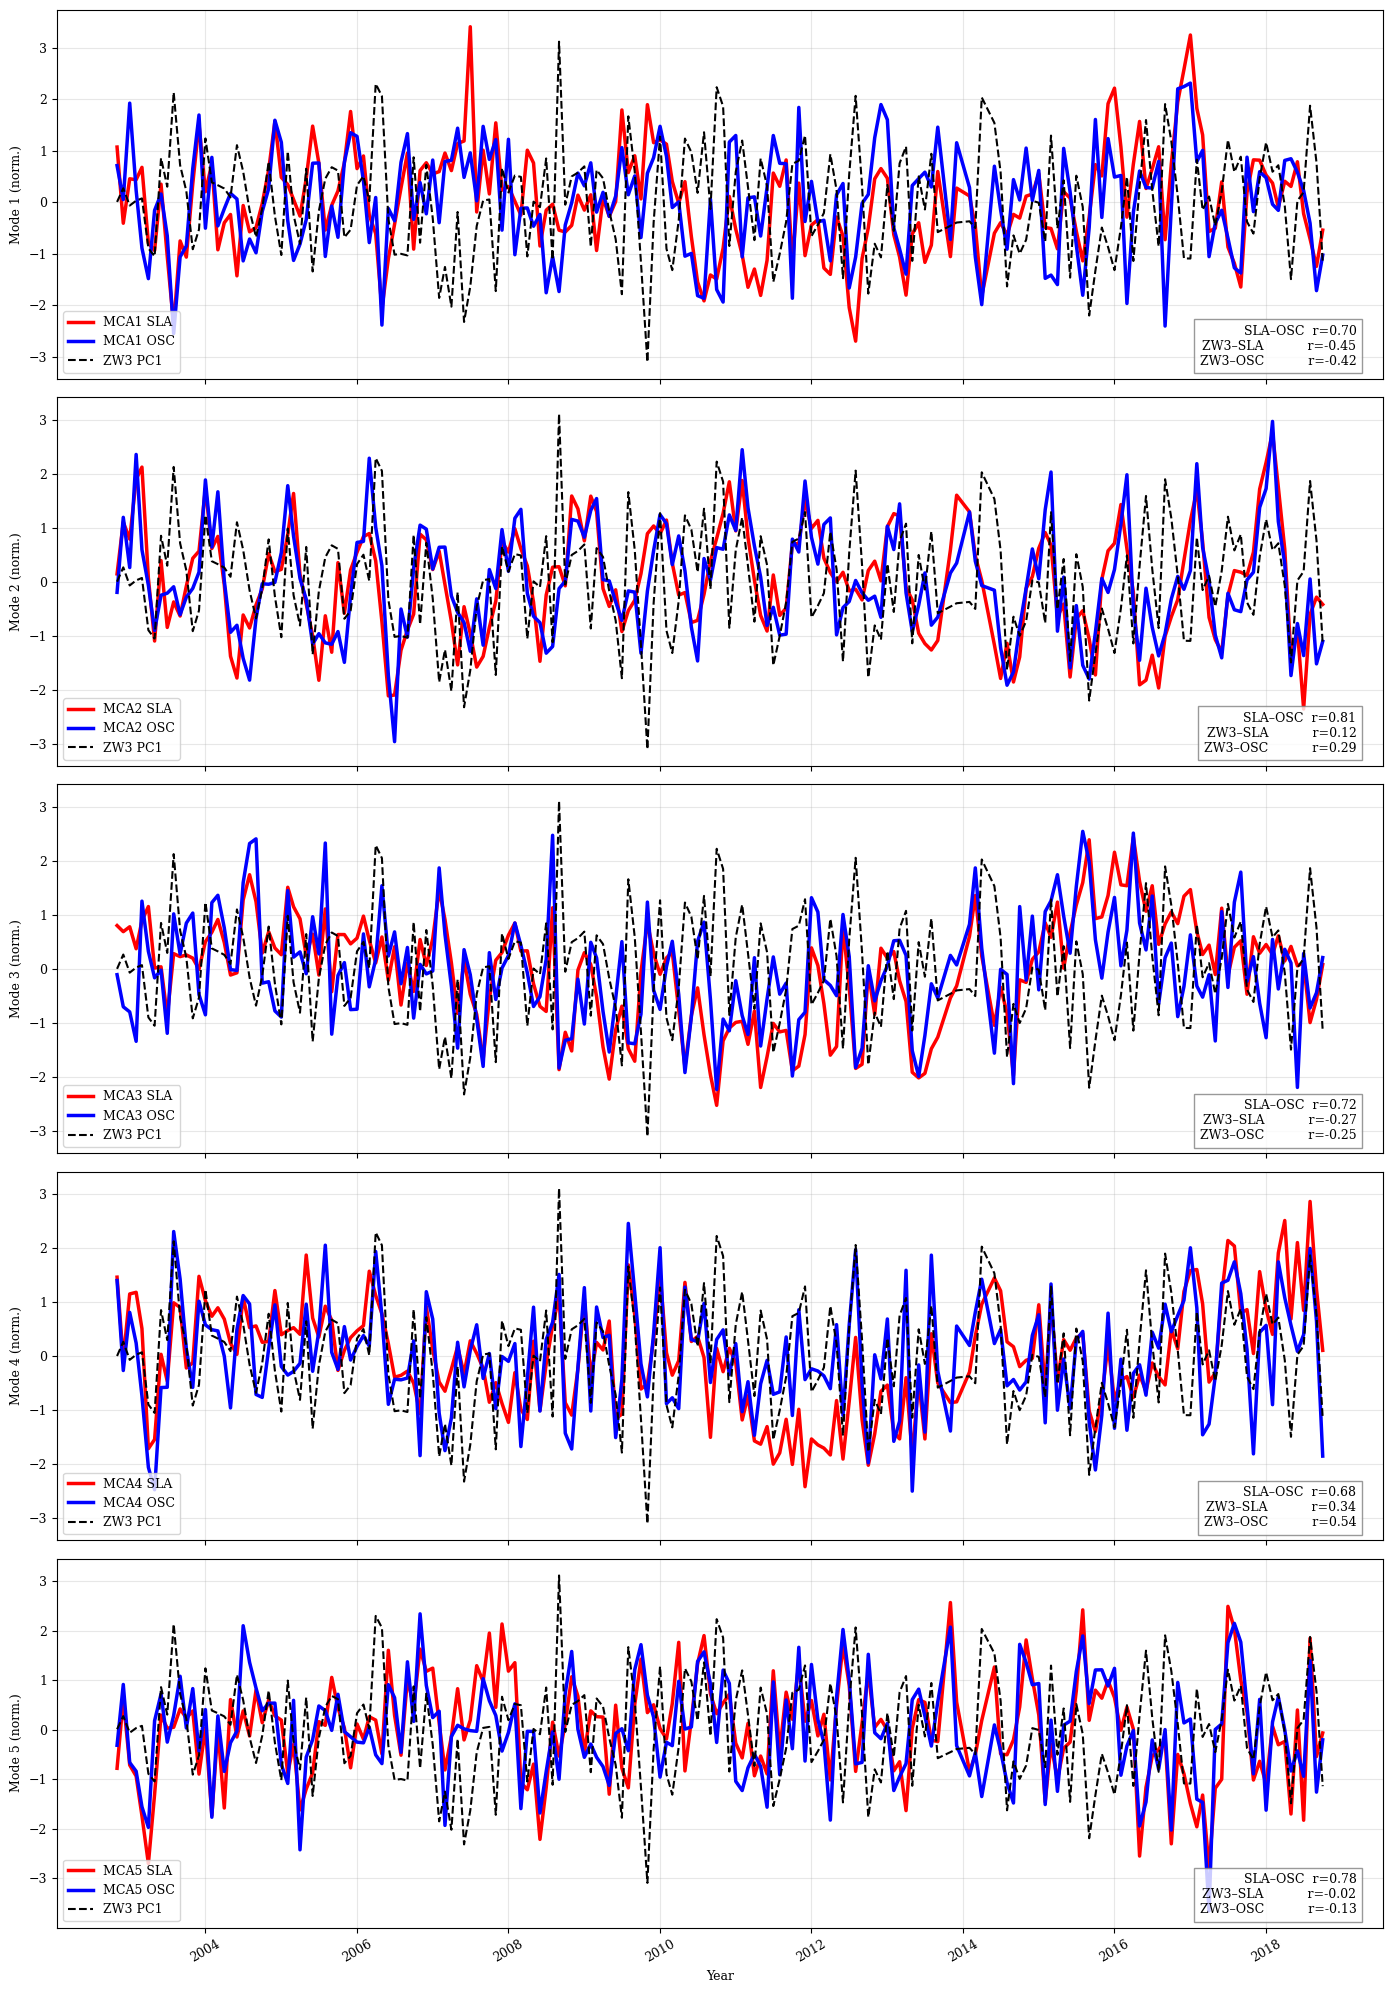

In [378]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align ZW3 ──────────────────────────────────────────────────────
zw3_ds  = xr.open_dataset(clim_dir + 'ZW3/zw3_2000_2024.nc')
zw3_da  = zw3_ds["pc1"] #zw3index_magnitude # zw3index_phase #pc1 #pc2

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(zw3_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

# index_da   = zw3_da.sel(time=common_time)
# index_norm = (index_da - index_da.mean()) / index_da.std()

ref_start = '2002-11'
ref_end   = '2018-10'

# Select full period for plotting
index_da = zw3_da.sel(time=common_time)

# Detrend over reference period first
index_ref = index_da.sel(time=slice(ref_start, ref_end))

t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

# Apply detrend fit to the FULL time series (using same slope/intercept)
t_full       = np.arange(len(index_da))
trend_full   = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

# Standardise using reference period mean and std
ref_mean = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std  = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 5
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='ZW3 PC1')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'ZW3–{var_1_name}           r={r_i1:.2f}\n'
        f'ZW3–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

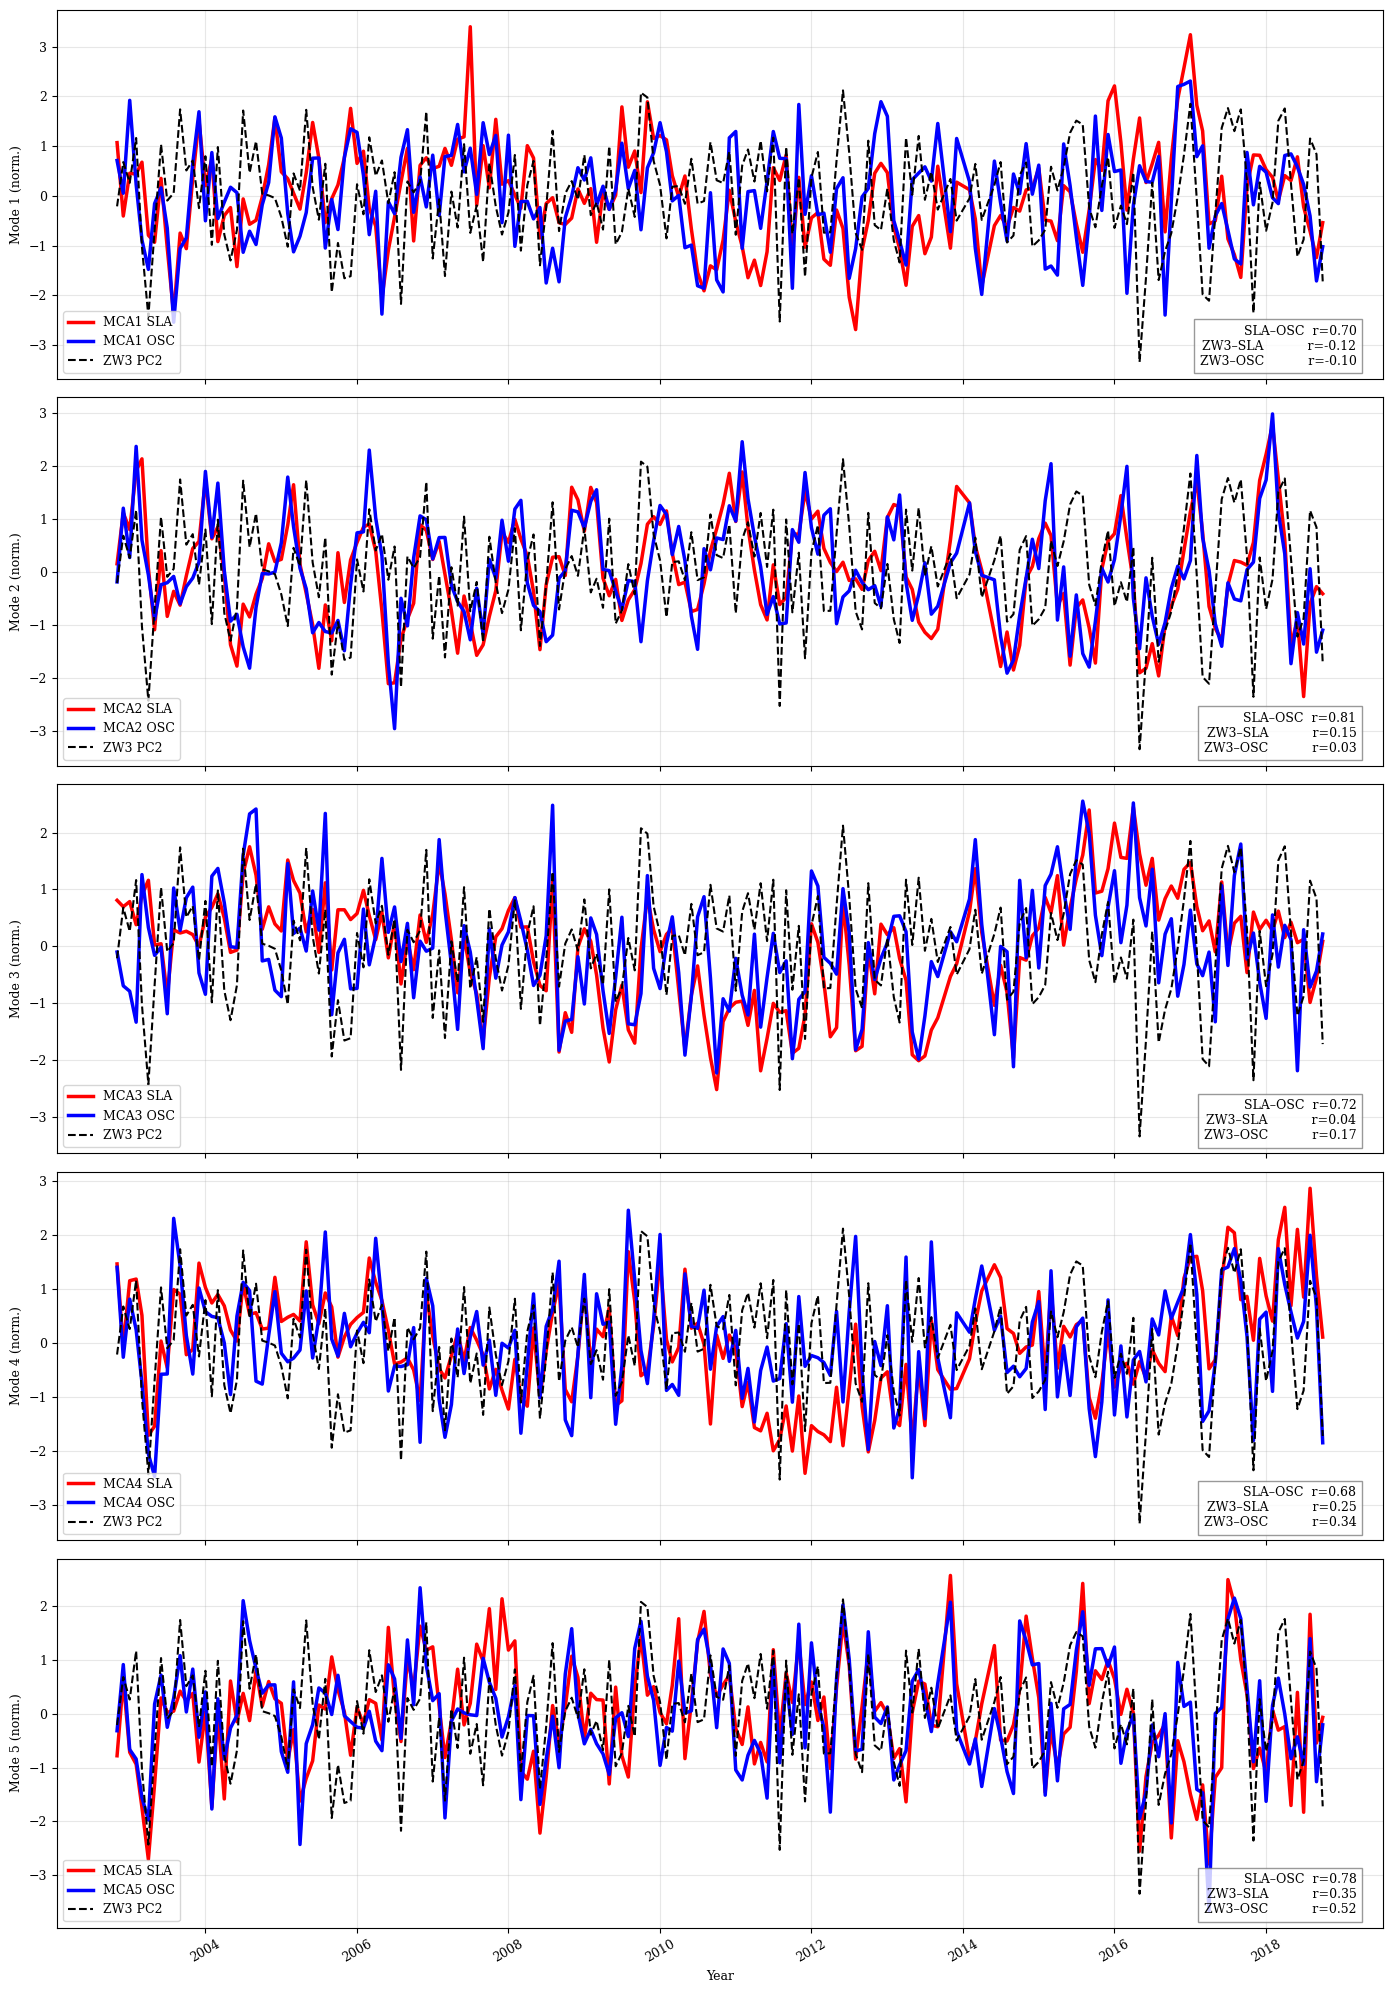

In [379]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align ZW3 ──────────────────────────────────────────────────────
zw3_ds  = xr.open_dataset(clim_dir + 'ZW3/zw3_2000_2024.nc')
zw3_da  = zw3_ds["pc2"] #zw3index_magnitude # zw3index_phase #pc1 #pc2

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(zw3_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

# index_da   = zw3_da.sel(time=common_time)
# index_norm = (index_da - index_da.mean()) / index_da.std()

ref_start = '2002-11'
ref_end   = '2018-10'

# Select full period for plotting
index_da = zw3_da.sel(time=common_time)

# Detrend over reference period first
index_ref = index_da.sel(time=slice(ref_start, ref_end))

t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

# Apply detrend fit to the FULL time series (using same slope/intercept)
t_full       = np.arange(len(index_da))
trend_full   = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

# Standardise using reference period mean and std
ref_mean = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std  = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 5
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    r_12, _ = scipy.stats.pearsonr(s1_n.values, s2_n.values)
    r_i1, _ = scipy.stats.pearsonr(index_norm.values, s1_n.values)
    r_i2, _ = scipy.stats.pearsonr(index_norm.values, s2_n.values)

    ax.plot(s1_n.time, s1_n, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_n, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_norm, '--', color='black', label='ZW3 PC2')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'ZW3–{var_1_name}           r={r_i1:.2f}\n'
        f'ZW3–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
# fig.suptitle(f'MCA modes vs SAM — {sector_name} ({suffix})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [380]:
print("llon edges:", llon[0, 0], llon[0, -1])   # should be ~ -180, 180
print("oss_x NaN fraction:", np.isnan(oss_x[:,:,0]).mean())  # how gappy is it?
print("osc magnitude before fix:", np.nanmax(np.abs(os_curl)))   # should be ~1e-7

llon edges: -179.5 179.5
oss_x NaN fraction: 0.350390625
osc magnitude before fix: 2.210942210786557e-06


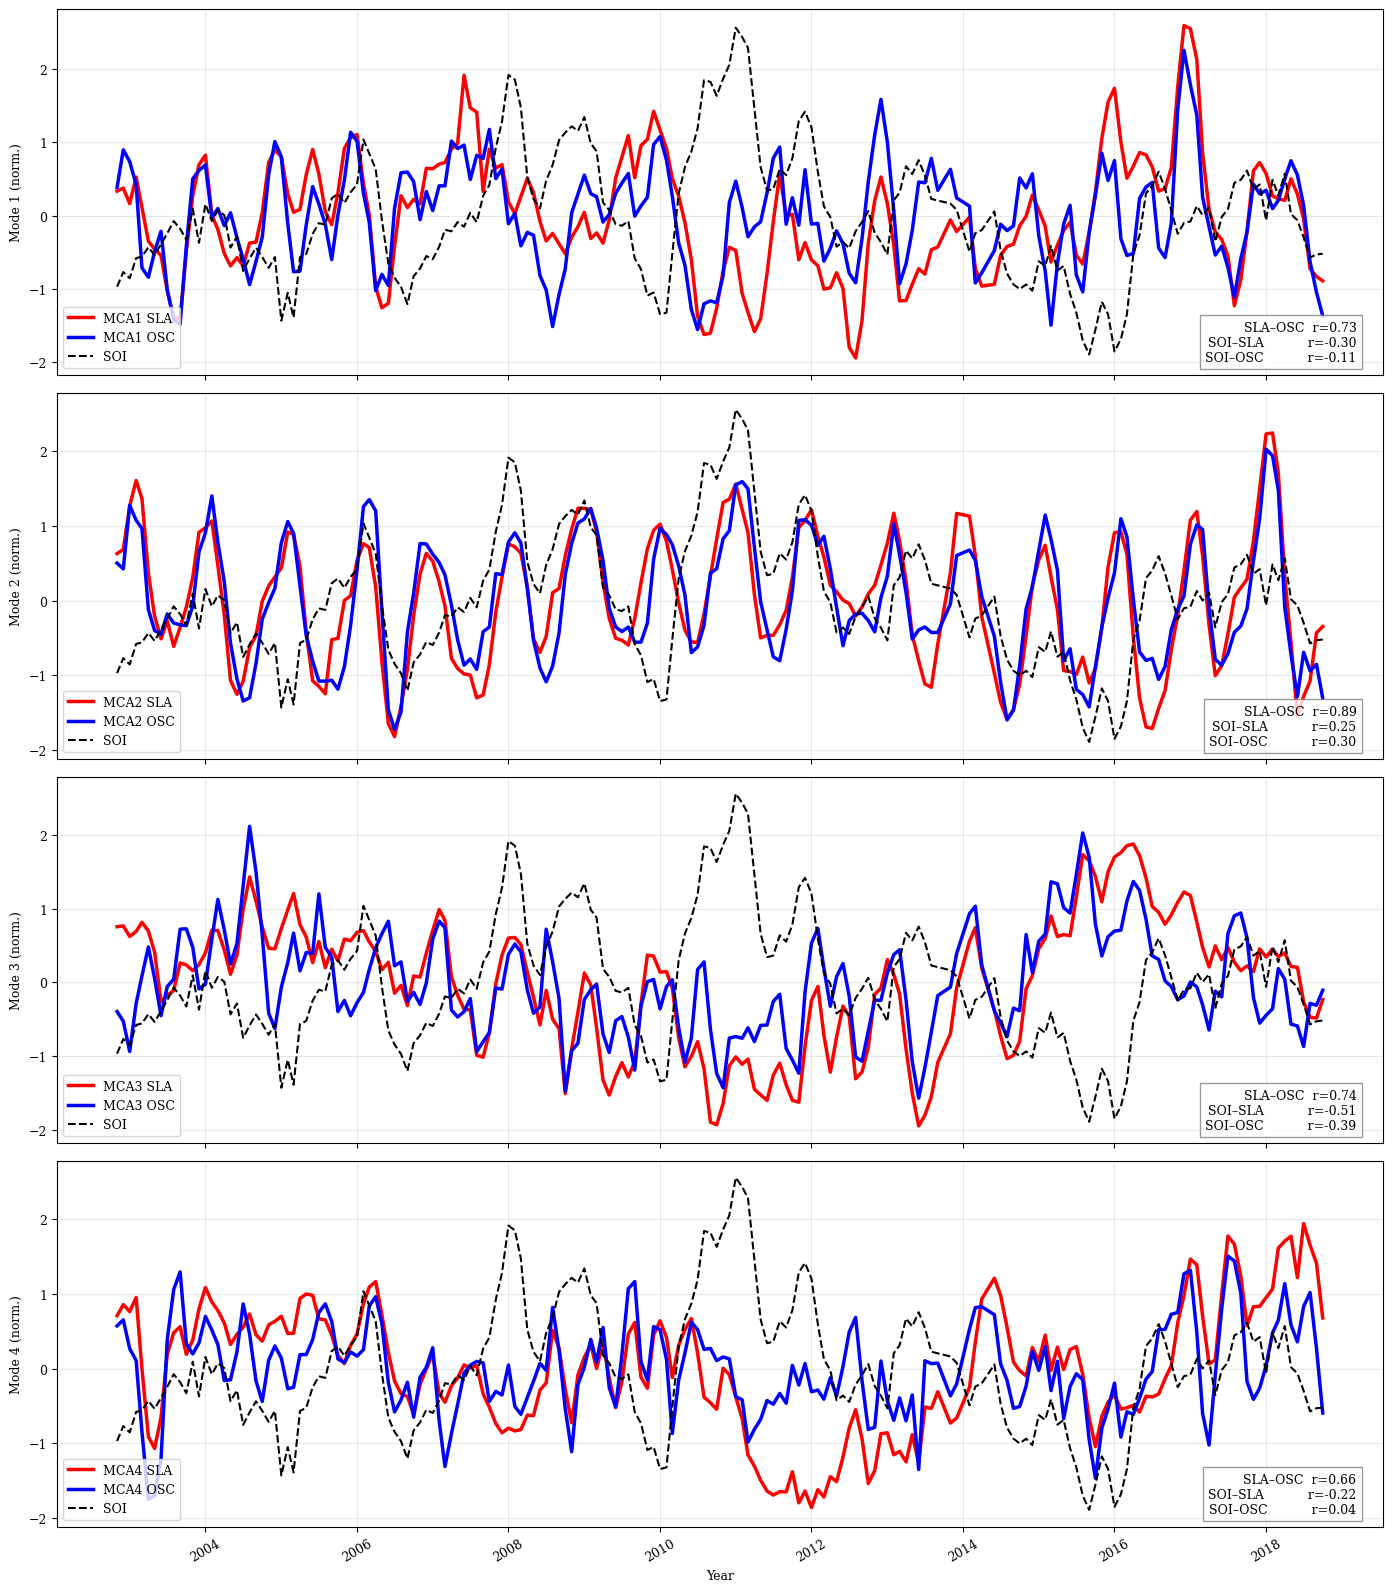

In [381]:
import scipy.stats
import matplotlib.pyplot as plt
import numpy as np

# ── load & align SAM ──────────────────────────────────────────────────────
soi_ds  = xr.open_dataset(clim_dir + 'SOI/soi_2000_2024.nc')
soi_da  = soi_ds["SOI"]

time_start = '2002-11'
time_end   = '2024-12'

common_time = np.intersect1d(soi_ds.time.values, scores1.time.values)
common_time = common_time[common_time >= np.datetime64(time_start)]
common_time = common_time[common_time <= np.datetime64(time_end)]

ref_start = '2002-11'
ref_end   = '2018-10'

index_da = soi_da.sel(time=common_time)

index_ref = index_da.sel(time=slice(ref_start, ref_end))
t_ref   = np.arange(len(index_ref))
slope, intercept, _, _, _ = scipy.stats.linregress(t_ref, index_ref.values)

t_full          = np.arange(len(index_da))
trend_full      = slope * t_full + intercept
index_detrended = index_da - xr.DataArray(trend_full, coords=[index_da.time], dims='time')

ref_mean   = index_detrended.sel(time=slice(ref_start, ref_end)).mean()
ref_std    = index_detrended.sel(time=slice(ref_start, ref_end)).std()
index_norm = (index_detrended - ref_mean) / ref_std

# ── 3-month rolling mean on SOI ───────────────────────────────────────────
index_smooth = index_norm.rolling(time=3, center=True, min_periods=2).mean()

# ── plot ──────────────────────────────────────────────────────────────────
n_modes = 4
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes), sharex=True)

for i, ax in enumerate(axes):
    m = i + 1

    s1 = scores1.sel(mode=m, time=common_time)
    s2 = scores2.sel(mode=m, time=common_time)
    s1_n = (s1 - s1.mean()) / s1.std()
    s2_n = (s2 - s2.mean()) / s2.std()

    # ── 3-month rolling mean on scores ────────────────────────────────────
    s1_smooth = s1_n.rolling(time=3, center=True, min_periods=2).mean()
    s2_smooth = s2_n.rolling(time=3, center=True, min_periods=2).mean()

    # ── correlations on smoothed series ───────────────────────────────────
    # drop NaNs introduced by rolling at edges before correlating
    valid = (np.isfinite(s1_smooth) & np.isfinite(s2_smooth) & np.isfinite(index_smooth))
    r_12, _ = scipy.stats.pearsonr(s1_smooth.values[valid], s2_smooth.values[valid])
    r_i1, _ = scipy.stats.pearsonr(index_smooth.values[valid], s1_smooth.values[valid])
    r_i2, _ = scipy.stats.pearsonr(index_smooth.values[valid], s2_smooth.values[valid])

    ax.plot(s1_n.time, s1_smooth, '-', color = 'red',linewidth = '2.5', label=f'MCA{m} {var_1_name}')
    ax.plot(s2_n.time, s2_smooth, '-', color = 'blue', linewidth = '2.5', label=f'MCA{m} {var_2_name}')
    ax.plot(index_norm.time, index_smooth, '--', color='black', label='SOI')

    ax.set_ylabel(f'Mode {m} (norm.)')
    ax.legend(fontsize=9, loc = 'lower left')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

    corr_txt = (
        f'{var_1_name}–{var_2_name}  r={r_12:.2f}\n'
        f'SOI–{var_1_name}           r={r_i1:.2f}\n'
        f'SOI–{var_2_name}           r={r_i2:.2f}'
    )
    ax.text(0.98, 0.03, corr_txt, transform=ax.transAxes,
            fontsize=9, va='bottom', ha='right',
            bbox=dict(facecolor='white', edgecolor='grey', alpha=0.8))

axes[-1].set_xlabel('Year')
fig.tight_layout()
plt.show()